# Using machine learning for outlier detection

We can use machine learning methods for outlier detection. Here is a prototype. 

We must solve a few issues before implementing this in production. Here is a summary of these issues.

* We lack the ground truth. We used synthetic labelled data for this experiment. We should use real labels. Machine learning models trained on incorrect labels will not perform well
* We lack a sufficiently large training dataset. Here, we used data from one station to train the model. Perhaps we can use training data from other stations, but we need to identify stations with similar behaviors. For example, data from the Barker Slough Pumping Plant in the San Francisco Bay will show different behavior than data from the Fallbrook Weather Station in the South Coast. Do we create geographic groups of stations? Or groups of stations in the same climate classification? This needs to be researched.
* We lack the infrastructure needed to conduct machine learning experiments. Right now, we are emailing data back and forth. Raw data from O&M is not publicly available. In an ideal case, we should perform the analysis in the same place as the data -- e.g. store the data cloud computing environment and co-locate the code with the compute.
* Ideally, use a tool to track experiments (e.g. MLflow).

Import packages. Note that the [`tsfresh`](https://github.com/blue-yonder/tsfresh) import will throw a warning. This [has been addressed](https://github.com/blue-yonder/tsfresh/issues/1115), but the `tsfresh` developers have not cut a release since this fix. We will continue to use the most stable recent release.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime as dt_obj
from IPython.display import display
from scipy import stats
from pandas.api.types import is_datetime64_any_dtype
from tsfresh import feature_extraction
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from itertools import combinations
 
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 3000)

/Users/monica.bobra/Desktop/ODI/Projects/DWR/caldata-dsa-dwr/.venv/lib/python3.10/site-packages/tsfresh/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Data processing 

### Ingest sample data

In [2]:
def get_data_from_local_directory(filename, path):
    """
        Get data from a local directory.

        Parameters
        ----------
        filename : str
            Name of file to get from local directory.
        path : str
            Path to local directory.
        
        Returns
        -------
        df : pandas.DataFrame
            Dataframe containing data from local directory.
        
        Examples
        --------
        >>> get_data_from_local_directory('test.csv', 'data/')
    """
    file_with_path = path + filename
    df = pd.read_csv(file_with_path)
    
    return df

In [3]:
df = get_data_from_local_directory(filename='sample_data_BKS.csv', path='sample_data/')

In [4]:
df

,STATION_ID,DURATION,SENSOR_NUMBER,SENSOR_TYPE,DATE TIME,OBS DATE,VALUE,DATA_FLAG,UNITS
0,BKS,D,62,PH VAL,19890203 0000,19890203 0100,---,,PH
1,BKS,D,62,PH VAL,19890204 0000,19890204 0000,---,,PH
2,BKS,D,62,PH VAL,19890205 0000,19890205 0000,---,,PH
3,BKS,D,62,PH VAL,19890206 0000,19890206 0000,---,,PH
4,BKS,D,62,PH VAL,19890207 0000,19890207 0000,---,,PH
...,...,...,...,...,...,...,...,...,...
12914,BKS,D,62,PH VAL,20241207 0000,20241207 0000,7.4,,PH
12915,BKS,D,62,PH VAL,20241208 0000,20241208 0000,7.5,,PH
12916,BKS,D,62,PH VAL,20241209 0000,20241209 0000,7.5,,PH
12917,BKS,D,62,PH VAL,20241210 0000,20241210 0000,7.5,,PH


Convert all string values of '---' to `np.Nan`

In [5]:
df.replace(to_replace='---', value=np.nan, inplace=True)

Convert string values in `DATE TIME` column to datetime object, rename it `TIME`, and set it as the index.

In [6]:
df['DATE TIME']=pd.to_datetime(df['DATE TIME'], format='%Y%m%d %H%M').reset_index(drop=True)

In [7]:
df = df.set_index('DATE TIME')

Convert all string values of numbers to ints for the column `VALUE`

In [8]:
df.VALUE = pd.to_numeric(df.VALUE)

Text(0.5, 1.0, 'Barker Slough Pumping Plant (BKS)')

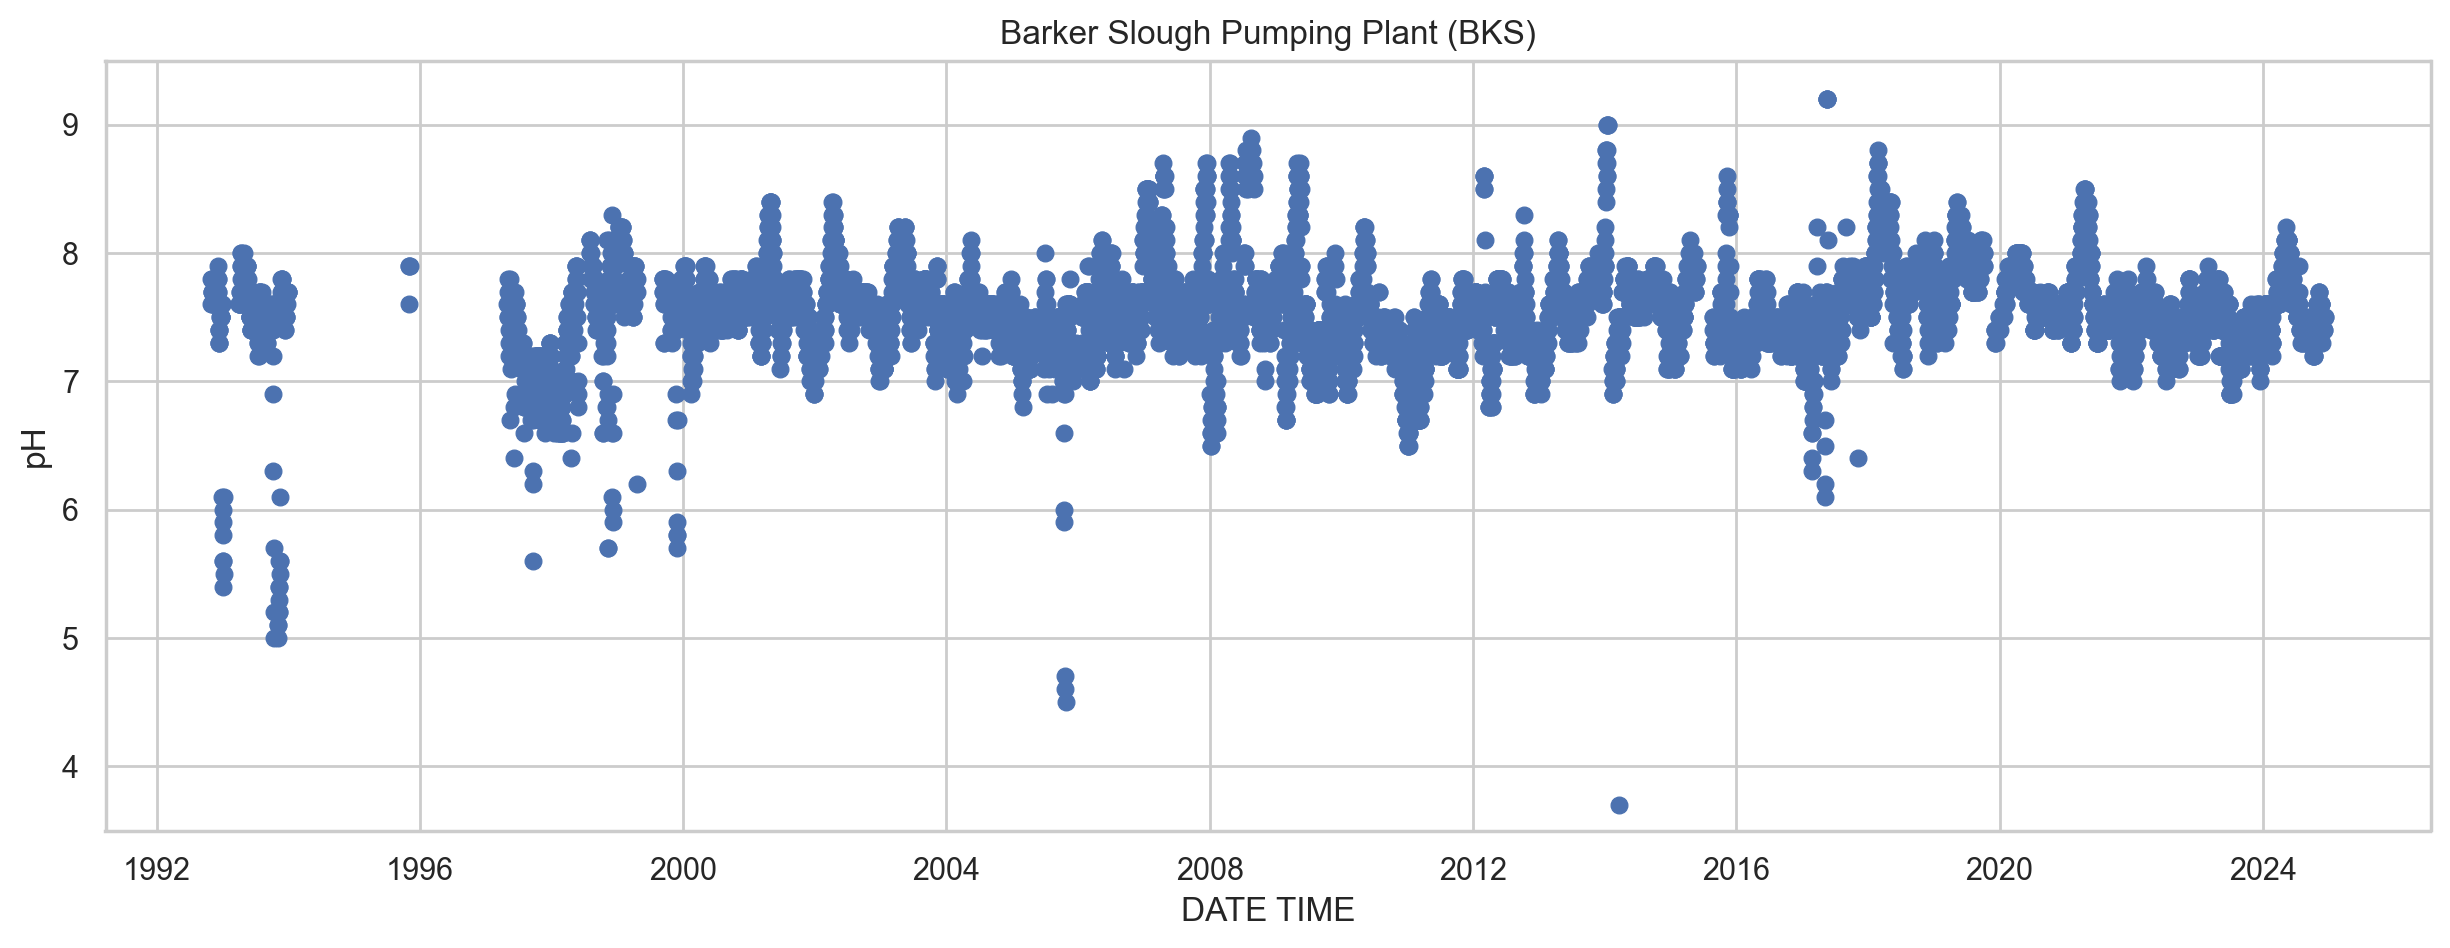

In [9]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15,5))
sns.scatterplot(df, x='DATE TIME', y='VALUE', edgecolor=None)
plt.ylim([3.5,9.5])
plt.ylabel('pH')
plt.title('Barker Slough Pumping Plant (BKS)')
#fig.savefig('initialdataset.png', dpi=300, transparent=True, bbox_inches='tight')

## Group 3 Tests

The following test uses a kNN method described in [Talagala+2019](http://dx.doi.org/10.1029/2019WR024906). Group 3 of the [Outlier Detection Test Best Practices](https://docs.google.com/document/d/1YmXWDMHCKnWniQ4sMkkT5g5j5H5TmT3f/edit) document suggests using machine-learning methods for outlier detection tests.

Right now, we are using univariate data (pH). Ideally, we could detect outliers using multivariate methods.

#### Step 1. Read the labelled data.

* We do not have any labelled data. Ask Daniel Wisheropp for true and false outliers for historical data. Right now, we are reading data that was artificially flagged using the outlier detection tool. Ideally, we would have a list of real outliers.

In [10]:
df = get_data_from_local_directory(filename='flagged_sample_data_BKS.csv', path='sample_data/')

In [11]:
# Convert to datetime object
df['DATE TIME']=pd.to_datetime(df['DATE TIME'], format='%Y-%m-%d').reset_index(drop=True)

In [12]:
print(df['VALUE_failed_modified_z_score_test'].value_counts())
print(df['VALUE_failed_spike_detection_test'].value_counts())
print(df['VALUE_failed_value_gap_test'].value_counts())
print(df['VALUE_failed_z_score_test'].value_counts())
print(df['VALUE_failed_flat_line_test'].value_counts())
print(df['DATE TIME_failed_time_gap_test'].value_counts())
print(df['VALUE_failed_tukey_iqr_test'].value_counts())
print(len(df))

VALUE_failed_modified_z_score_test
failed    45
Name: count, dtype: int64
VALUE_failed_spike_detection_test
failed    1
Name: count, dtype: int64
VALUE_failed_value_gap_test
failed    3541
Name: count, dtype: int64
VALUE_failed_z_score_test
failed    50
Name: count, dtype: int64
VALUE_failed_flat_line_test
failed    190
Name: count, dtype: int64
DATE TIME_failed_time_gap_test
failed    12918
Name: count, dtype: int64
VALUE_failed_tukey_iqr_test
failed    568
Name: count, dtype: int64
12919


In [13]:
# Create a single binary flag
df['Flag'] = np.where(((df['VALUE_failed_modified_z_score_test'] == 'failed') | 
                       (df['VALUE_failed_spike_detection_test'] == 'failed') |
                       (df['VALUE_failed_value_gap_test'] == 'failed') |
                       (df['VALUE_failed_z_score_test'] == 'failed') |
                       (df['VALUE_failed_flat_line_test'] == 'failed') |
                       (df['VALUE_failed_tukey_iqr_test'])), 1, 0)

In [14]:
df['Flag'].value_counts()

Flag
0    8619
1    4300
Name: count, dtype: int64

In [15]:
df_subset = df[['VALUE', 'DATE TIME', 'Flag']]

In [16]:
# if VALUE has a NaN then drop it
df_clean = df_subset[df_subset['VALUE'].notna()].reset_index(drop=True)

In [17]:
df_clean['Flag'].value_counts()

Flag
0    8619
1     759
Name: count, dtype: int64

Text(0.5, 1.0, 'Barker Slough Pumping Plant (BKS)')

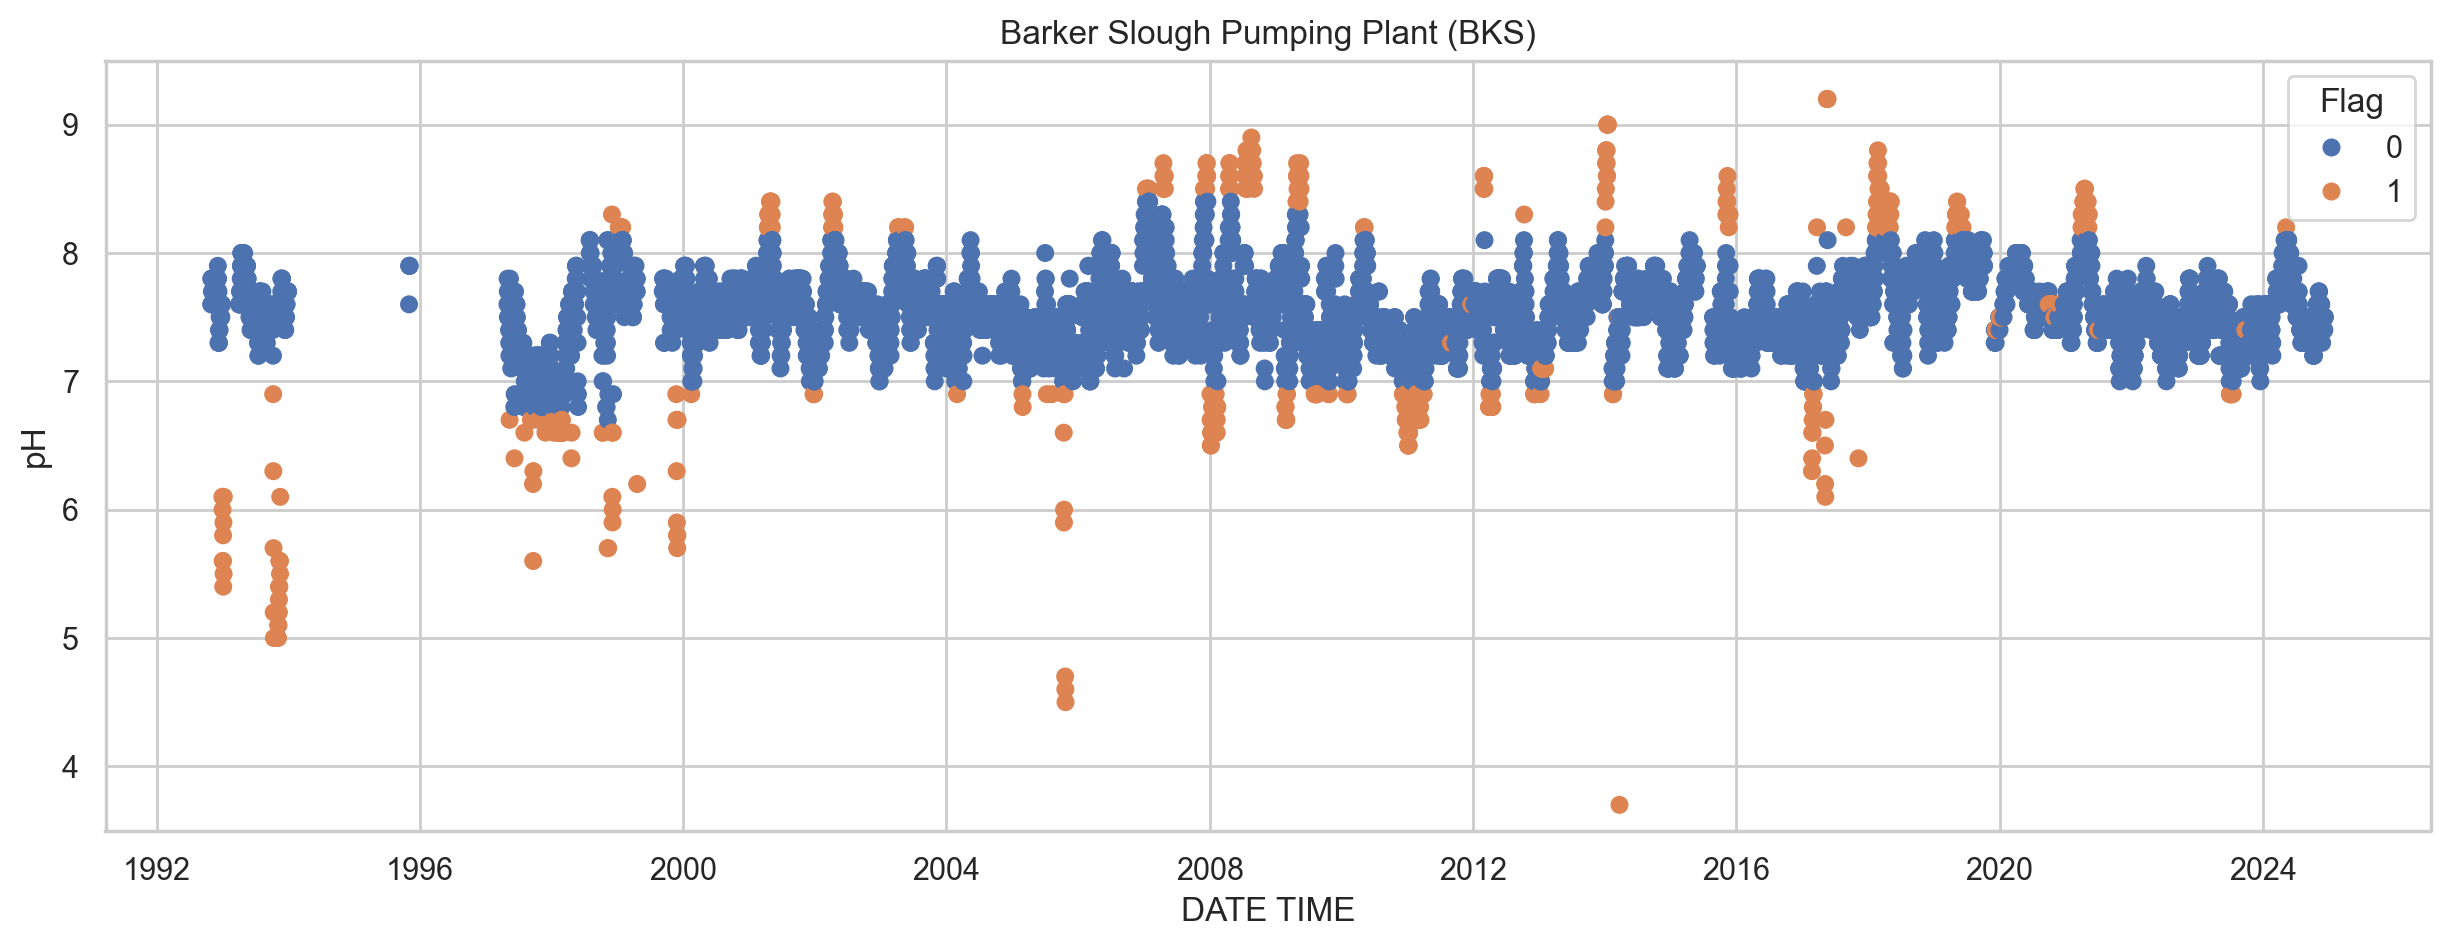

In [18]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15,5))
sns.scatterplot(df_clean, x='DATE TIME', y='VALUE', hue='Flag', edgecolor=None)
plt.ylim([3.5,9.5])
plt.ylabel('pH')
plt.title('Barker Slough Pumping Plant (BKS)')
#fig.savefig('labelleddataset.png', dpi=300, transparent=True, bbox_inches='tight')

#### Step 2. Derive features from the data.

* Right now, we are creating simple features in the temporal domain using the Python package [tsfresh](https://tsfresh.readthedocs.io/en/latest/). See [here](https://tsfresh.readthedocs.io/en/latest/text/list_of_features.html) for a list of available features. We will begin with a subset of six features.
* In the future, we can look at the spectral domain (e.g. Fourier space). Future ideas also include computing features with convolutional kernels (e.g. [ROCKET](https://www.aeon-toolkit.org/en/stable/examples/transformations/rocket.html)).

In [19]:
# Create a one-week rolling time window
one_week = pd.Timedelta('7 days')
two_weeks = pd.Timedelta('14 days')
df_rolled = df_clean[['VALUE', 'DATE TIME']].rolling(window = one_week, on='DATE TIME')
df_rolled_two_weeks = df_clean[['VALUE', 'DATE TIME']].rolling(window = two_weeks, on='DATE TIME')

In [20]:
# Calculate absolute sum of changes
def calculate_absolute_sum_of_changes(n):
    return feature_extraction.feature_calculators.absolute_sum_of_changes(n)

# Calculate autocorrelation
def calculate_autocorrelation(n):
    return feature_extraction.feature_calculators.autocorrelation(n, lag=7)

# Calculate number of peaks in the window
def calculate_number_cwt_peaks(n):
    return feature_extraction.feature_calculators.number_cwt_peaks(n, n=7)

# Calculate a measure of complexity
def calculate_absolute_complexity(n):
    return feature_extraction.feature_calculators.cid_ce(n, normalize = False)

# Calculate the absolute maximum
def calculate_absolute_maximum(n):
    return feature_extraction.feature_calculators.absolute_maximum(n)

# Calculate large standard deviation
def calculate_large_standard_deviation(n):
    return feature_extraction.feature_calculators.large_standard_deviation(n, r=100)

In [21]:
df_absolute_sum_of_changes = df_rolled.apply(calculate_absolute_sum_of_changes).rename(columns={'VALUE':'Absolute sum of changes'})
df_autocorrelation = df_rolled_two_weeks.apply(calculate_autocorrelation).rename(columns={'VALUE':'Autocorrelation'})
df_number_cwt_peaks = df_rolled.apply(calculate_number_cwt_peaks).rename(columns={'VALUE':'Number of peaks'})
df_absolute_complexity = df_rolled.apply(calculate_absolute_complexity).rename(columns={'VALUE':'Absolute complexity'})
df_absolute_maximum = df_rolled.apply(calculate_absolute_maximum).rename(columns={'VALUE':'Absolute maximum'})
df_large_standard_deviation = df_rolled.apply(calculate_large_standard_deviation).rename(columns={'VALUE':'Large standard deviation'})

In [22]:
df_clean['Absolute sum of changes'] = df_absolute_sum_of_changes['Absolute sum of changes']
df_clean['Autocorrelation'] = df_autocorrelation['Autocorrelation']
df_clean['Number of peaks'] = df_number_cwt_peaks['Number of peaks']
df_clean['Absolute complexity'] = df_absolute_complexity['Absolute complexity']
df_clean['Absolute maximum'] = df_absolute_maximum['Absolute maximum']
df_clean['Large standard deviation'] = df_large_standard_deviation['Large standard deviation']

In [23]:
df_clean = df_clean[df_clean['Autocorrelation'].notna()].reset_index(drop=True)

In [24]:
df_clean.columns

Index(['VALUE', 'DATE TIME', 'Flag', 'Absolute sum of changes',
       'Autocorrelation', 'Number of peaks', 'Absolute complexity',
       'Absolute maximum', 'Large standard deviation'],
      dtype='object')

Text(0.5, 1.0, 'Barker Slough Pumping Plant (BKS)')

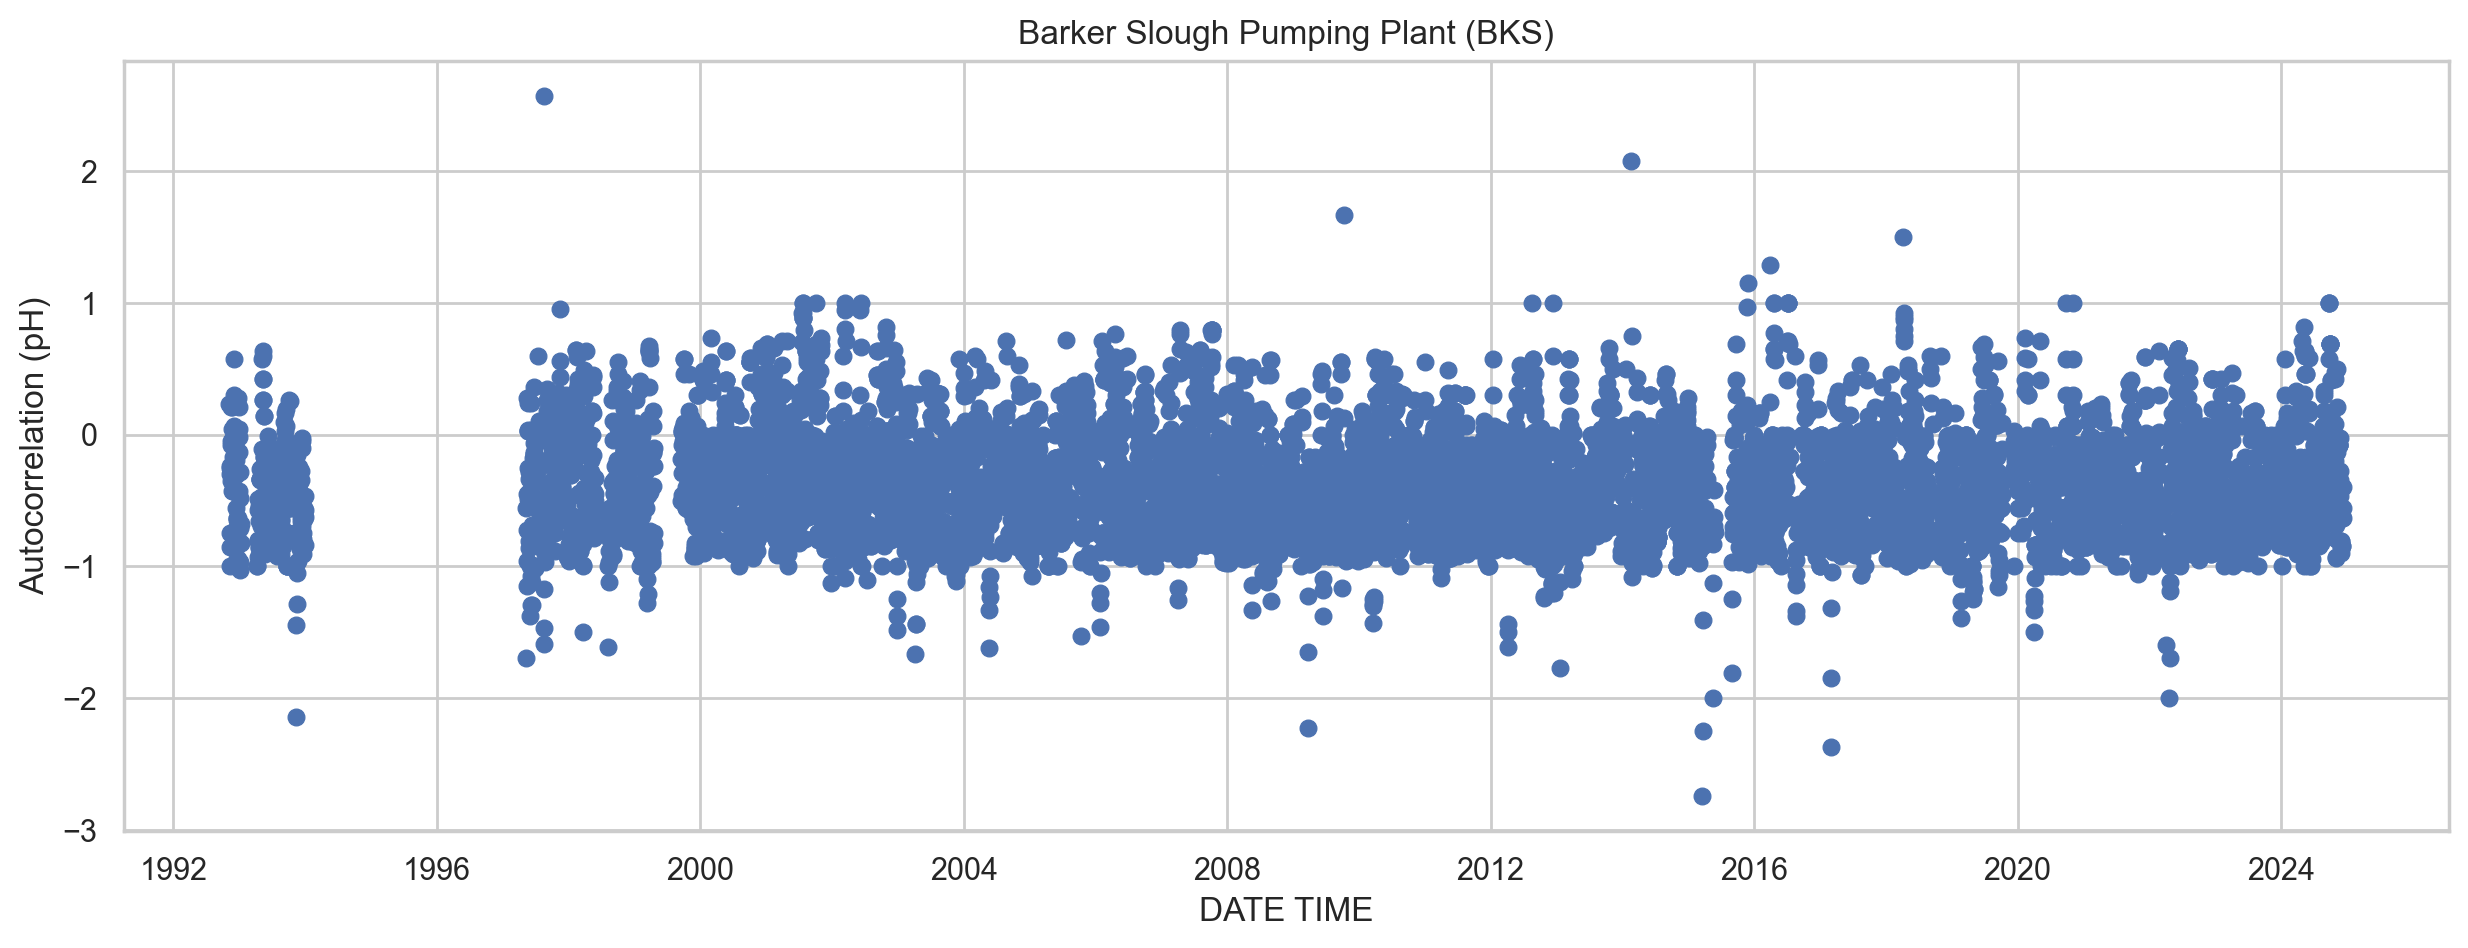

In [25]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15,5))
sns.scatterplot(df_clean, x='DATE TIME', y='Autocorrelation', edgecolor=None)
#plt.ylim([3.5,9.5])
plt.ylabel('Autocorrelation (pH)')
plt.title('Barker Slough Pumping Plant (BKS)')
#fig.savefig('Autocorrelation.png', dpi=300, transparent=True, bbox_inches='tight')

#### Step 3. Split the data into training and testing data.
Split based on time.

In [26]:
df_train = df_clean.iloc[0:int(len(df_clean)*0.7)]
df_test = df_clean.iloc[int(len(df_clean)*0.7):]

In [27]:
df_train['Flag'].value_counts()

Flag
0    5857
1     444
Name: count, dtype: int64

In [28]:
df_train.columns

Index(['VALUE', 'DATE TIME', 'Flag', 'Absolute sum of changes',
       'Autocorrelation', 'Number of peaks', 'Absolute complexity',
       'Absolute maximum', 'Large standard deviation'],
      dtype='object')

In [29]:
feature_names = ['Absolute sum of changes', 'Autocorrelation', 'Number of peaks', 'Absolute complexity', 'VALUE', 'Absolute maximum', 'Large standard deviation']

X = df_clean[feature_names]
y = df_clean['Flag']

X_train = df_train[feature_names].to_numpy()
y_train = df_train['Flag'].to_numpy()
X_test = df_test[feature_names].to_numpy()
y_test = df_test['Flag'].to_numpy()

In [30]:
X.columns

Index(['Absolute sum of changes', 'Autocorrelation', 'Number of peaks',
       'Absolute complexity', 'VALUE', 'Absolute maximum',
       'Large standard deviation'],
      dtype='object')

#### Step 4. Train the kNN algorithm and predict outliers

In [31]:
clf = KNeighborsClassifier(n_neighbors=3)

In [32]:
clf.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [33]:
y_pred = clf.predict(X_test)

#### Step 5. Validate model

In [34]:
def probability_based_confusion_matrix(y_val, y_pred):
    """
    This function takes in the validation set and the forecasted values
    and returns indices of the false positives, false negatives, true positives, and true negatives.

    Parameters:
    y_val: The validation set
    y_pred: The forecasted values

    Returns:
    examples_false_positive: The indices of the false positives
    examples_false_negative: The indices of the false negatives
    examples_true_positive: The indices of the true positives
    examples_true_negative: The indices of the true negatives

    Example:
    >>> probability_based_confusion_matrix(y_val, y_pred_probability)
    """
    
    # Set counter
    count_false_positive = 0
    count_false_negative = 0
    count_true_positive = 0
    count_true_negative = 0
    examples_false_positive = []
    examples_false_negative = []
    examples_true_positive = []
    examples_true_negative = []

    for i in range(len(y_val)):
        if ((y_val[i] == 0) and (y_pred[i] == 1)):
            count_false_positive += 1
            examples_false_positive.append(i)
        if ((y_val[i] == 1) and (y_pred[i] == 0)):
            count_false_negative += 1
            examples_false_negative.append(i)
        if ((y_val[i] == 0) and (y_pred[i] == 0)):
            count_true_negative += 1
            examples_true_negative.append(i)
        if ((y_val[i] == 1) and (y_pred[i] == 1)):
            count_true_positive += 1
            examples_true_positive.append(i)
    print('There were {} false positives.'.format(count_false_positive))
    print('There were {} false negatives.'.format(count_false_negative))
    print('There were {} true positives.'.format(count_true_positive))
    print('There were {} true negatives.'.format(count_true_negative))

    # Reset counter
    count = 0
    count_false_positive = 0
    count_false_negative = 0
    count_true_positive = 0
    count_true_negative = 0

    return examples_false_positive, examples_false_negative, examples_true_positive, examples_true_negative

In [35]:
examples_false_positive, examples_false_negative, examples_true_positive, examples_true_negative = probability_based_confusion_matrix(y_val=y_test, y_pred=y_pred)

There were 9 false positives.
There were 132 false negatives.
There were 86 true positives.
There were 2474 true negatives.


In [36]:
df_test = df_test.assign(prediction = y_pred)

Text(0.5, 1.0, 'Barker Slough Pumping Plant (BKS)')

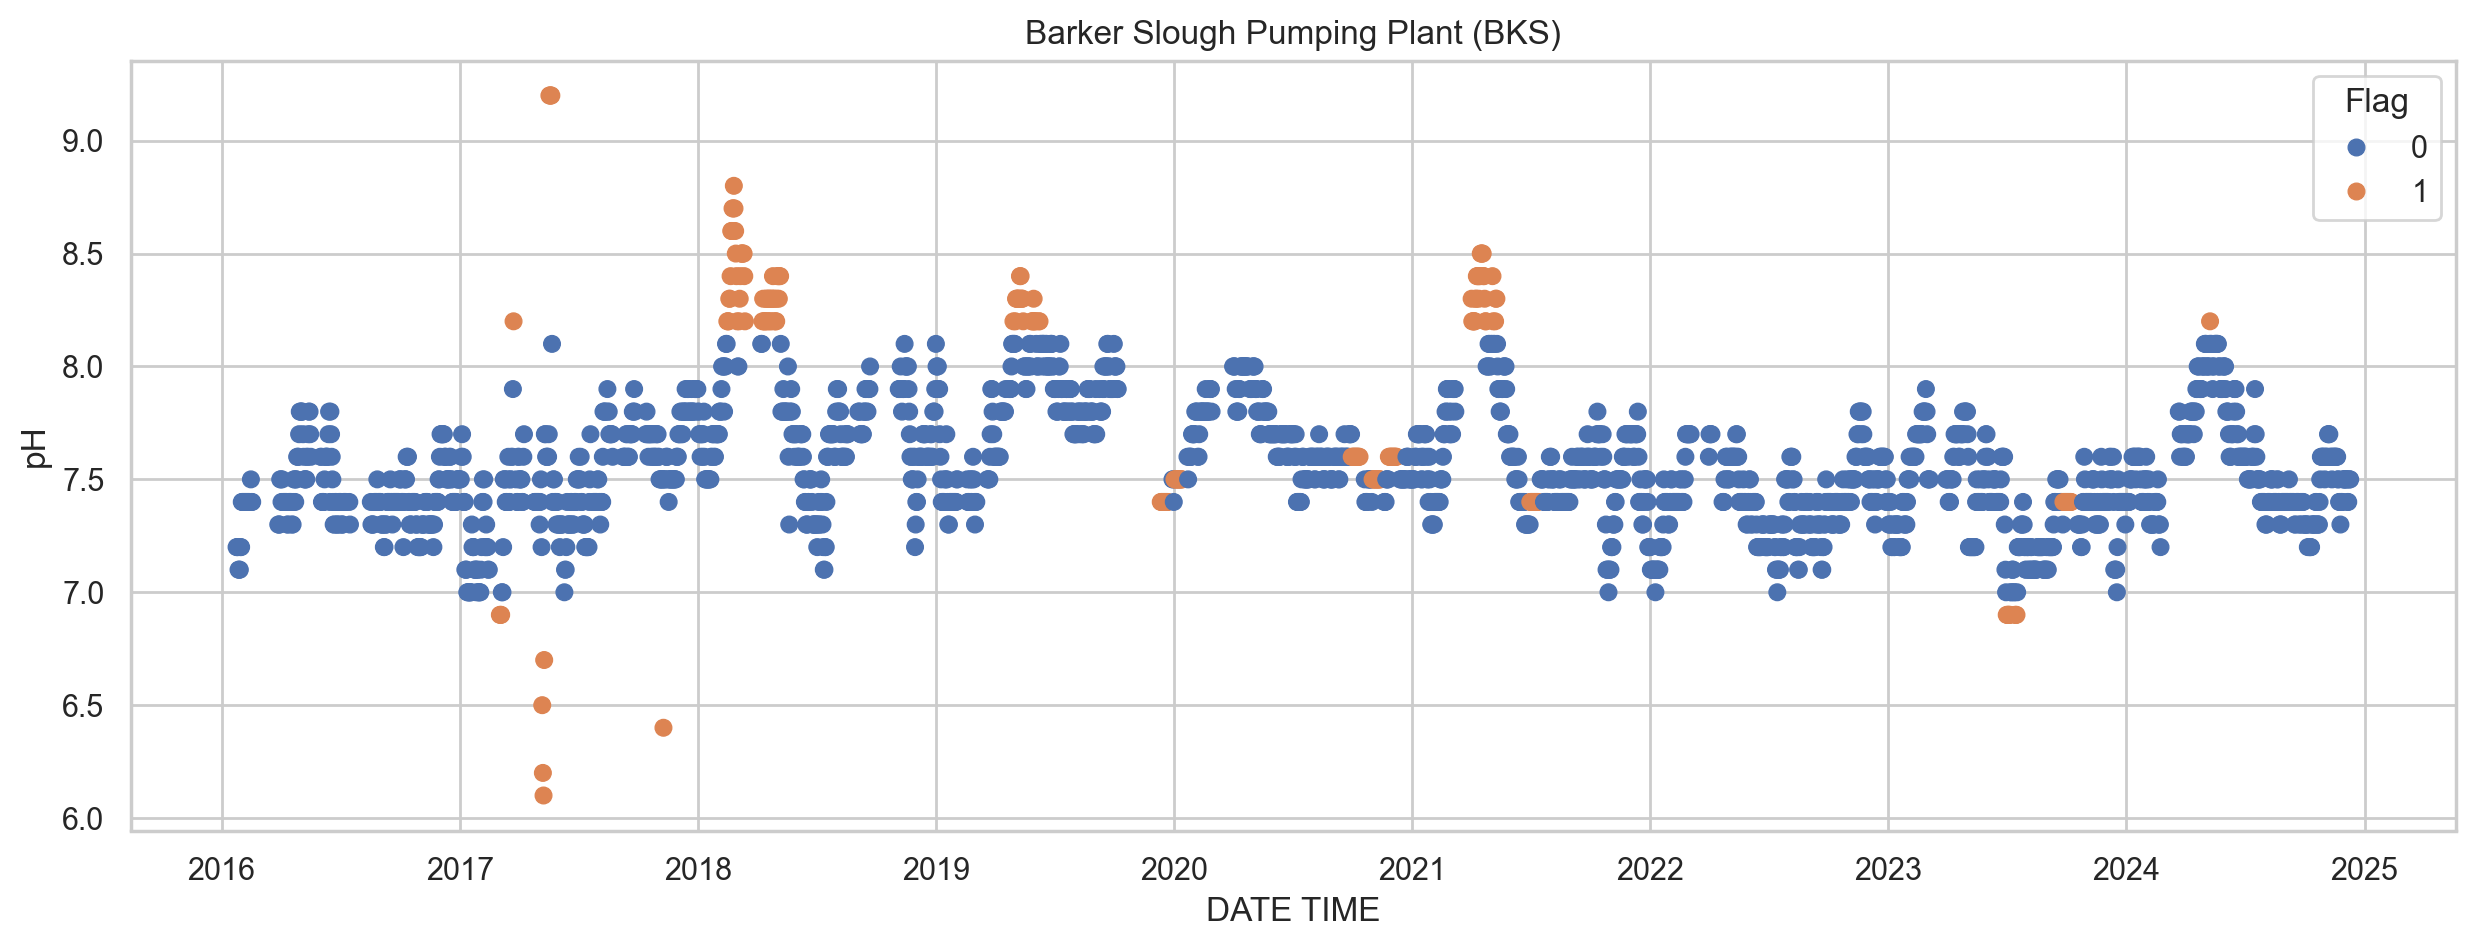

In [37]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15,5))
sns.scatterplot(df_test, x='DATE TIME', y='VALUE', hue='Flag', edgecolor=None)
plt.ylabel('pH')
plt.title('Barker Slough Pumping Plant (BKS)')
#fig.savefig('testdata_groundtruth.png', dpi=300, transparent=True, bbox_inches='tight')

Text(0.5, 1.0, 'Barker Slough Pumping Plant (BKS)')

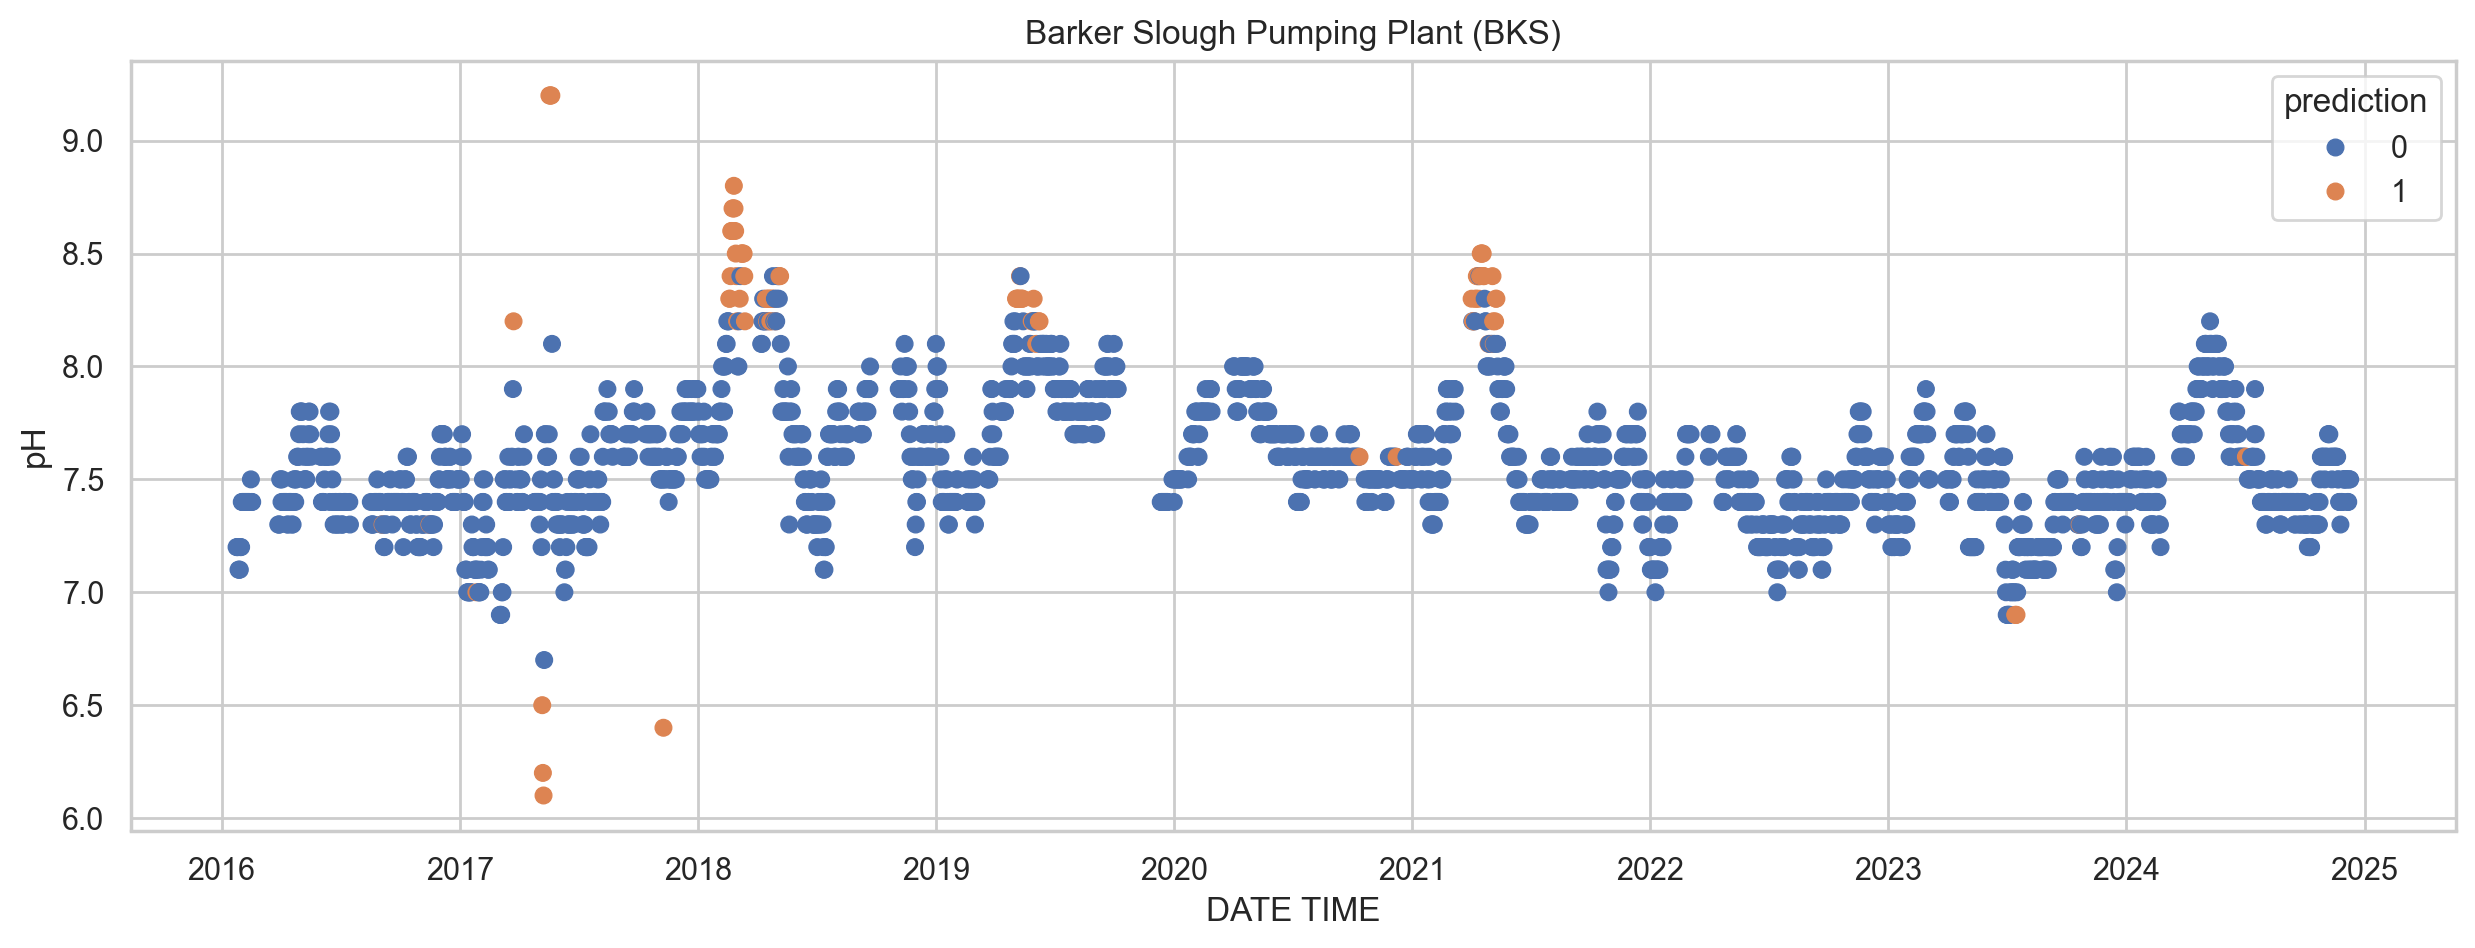

In [38]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15,5))
sns.scatterplot(df_test, x='DATE TIME', y='VALUE', hue='prediction', edgecolor=None)
plt.ylabel('pH')
plt.title('Barker Slough Pumping Plant (BKS)')
#fig.savefig('testdata_prediction.png', dpi=300, transparent=True, bbox_inches='tight')

#### Step 6. View the decision boundary

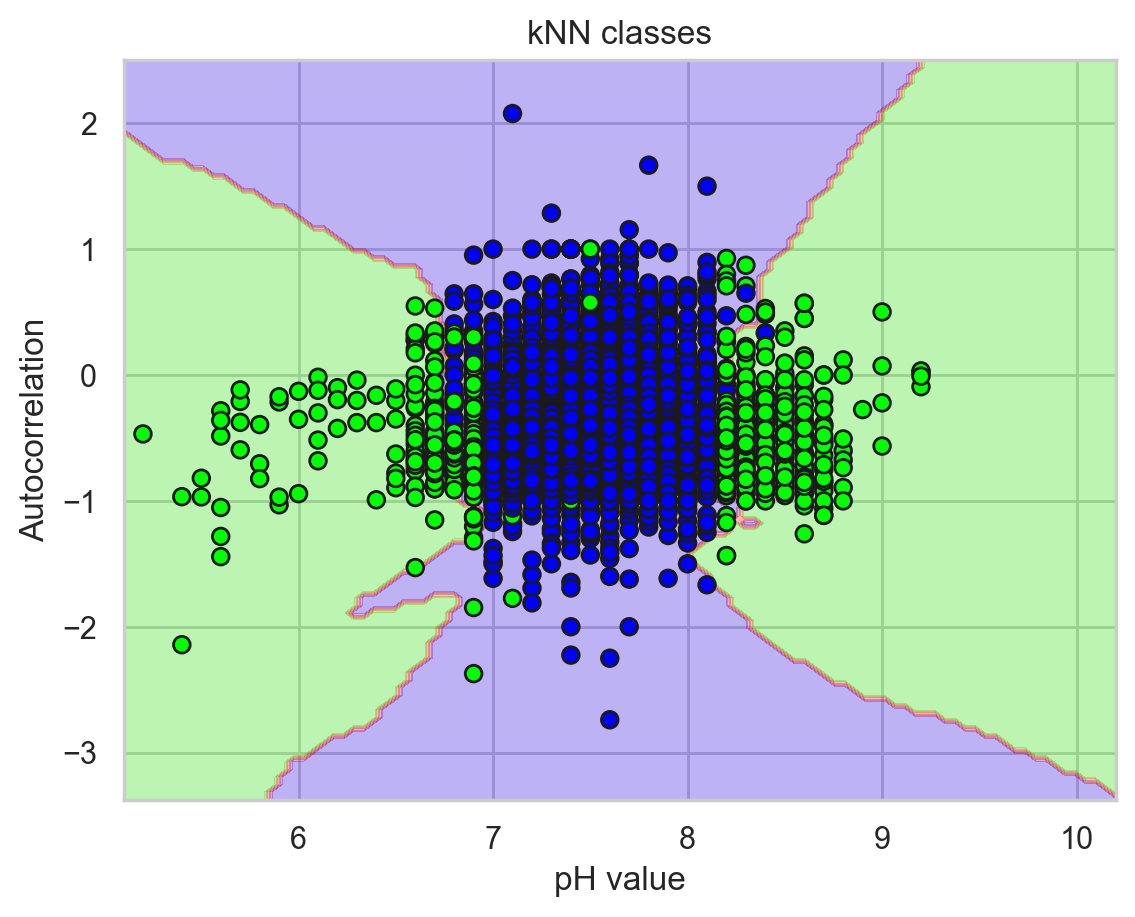

In [39]:
fig, ax = plt.subplots()
clf.fit(X_train[:,[4,1]], y_train)

disp = DecisionBoundaryDisplay.from_estimator(
    clf,
    X_test[:,[4,1]],
    response_method="predict",
    cmap=plt.cm.brg,
    xlabel="pH value",
    ylabel="Autocorrelation",
    alpha=0.3,
    ax=ax,
)

x_range_values = ax.get_xlim()
y_range_values = ax.get_ylim()

scatter = disp.ax_.scatter(X.iloc[:, 4], X.iloc[:, 1], c=y, cmap=plt.cm.brg, edgecolors="k")
plt.xlim(x_range_values)
plt.ylim(y_range_values)
plt.title('kNN classes')
plt.show()
#fig.savefig('kNN_classes.png', dpi=300, transparent=True, bbox_inches='tight')

In [40]:
pairs = list(combinations(range(len(X.columns)), 2))

0 1 Absolute sum of changes Autocorrelation


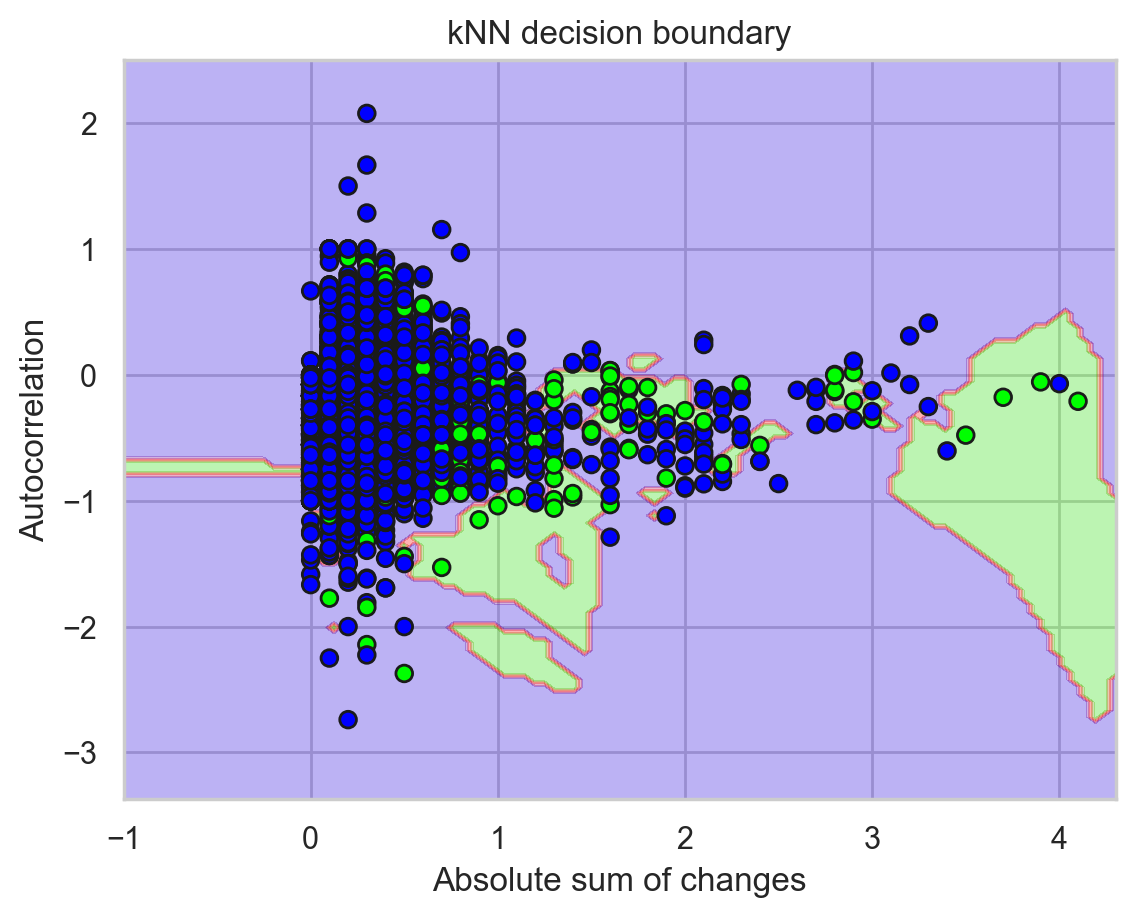

0 2 Absolute sum of changes Number of peaks


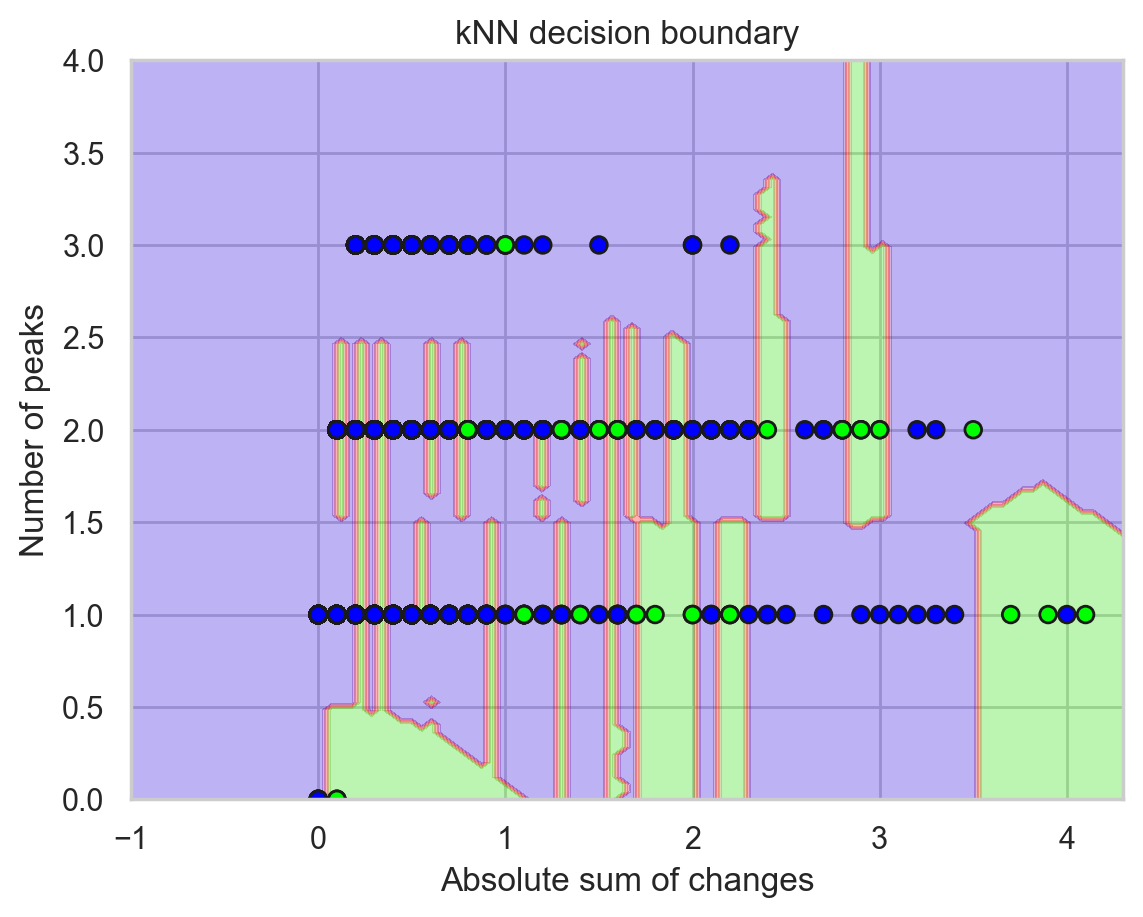

0 3 Absolute sum of changes Absolute complexity


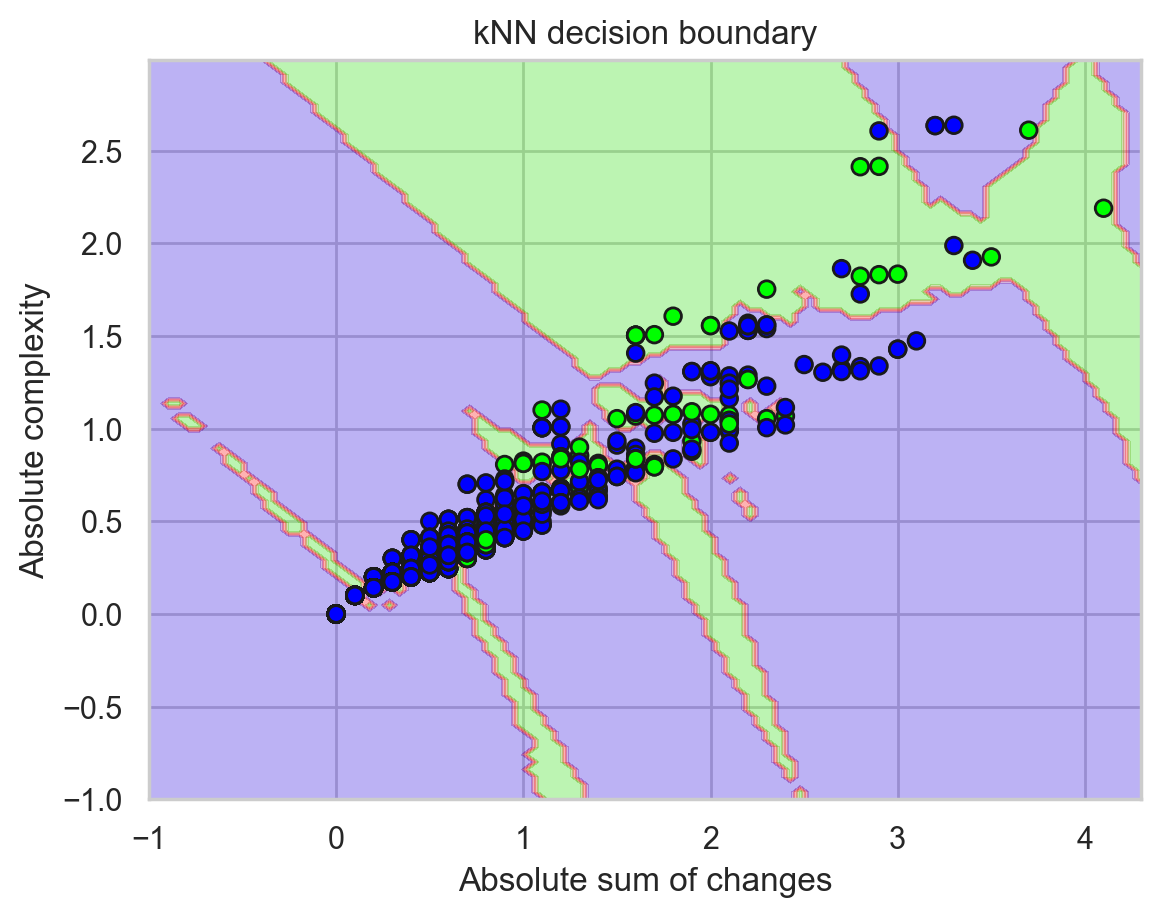

0 4 Absolute sum of changes VALUE


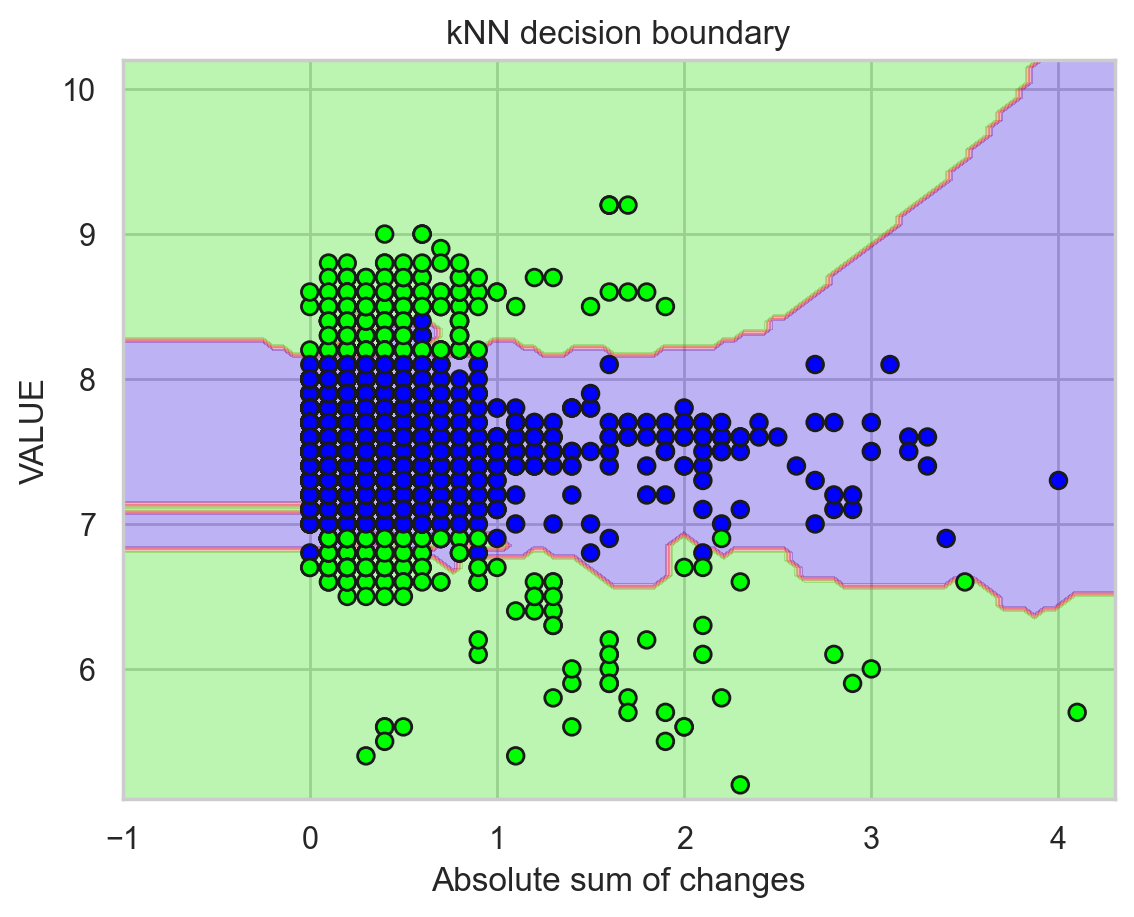

0 5 Absolute sum of changes Absolute maximum


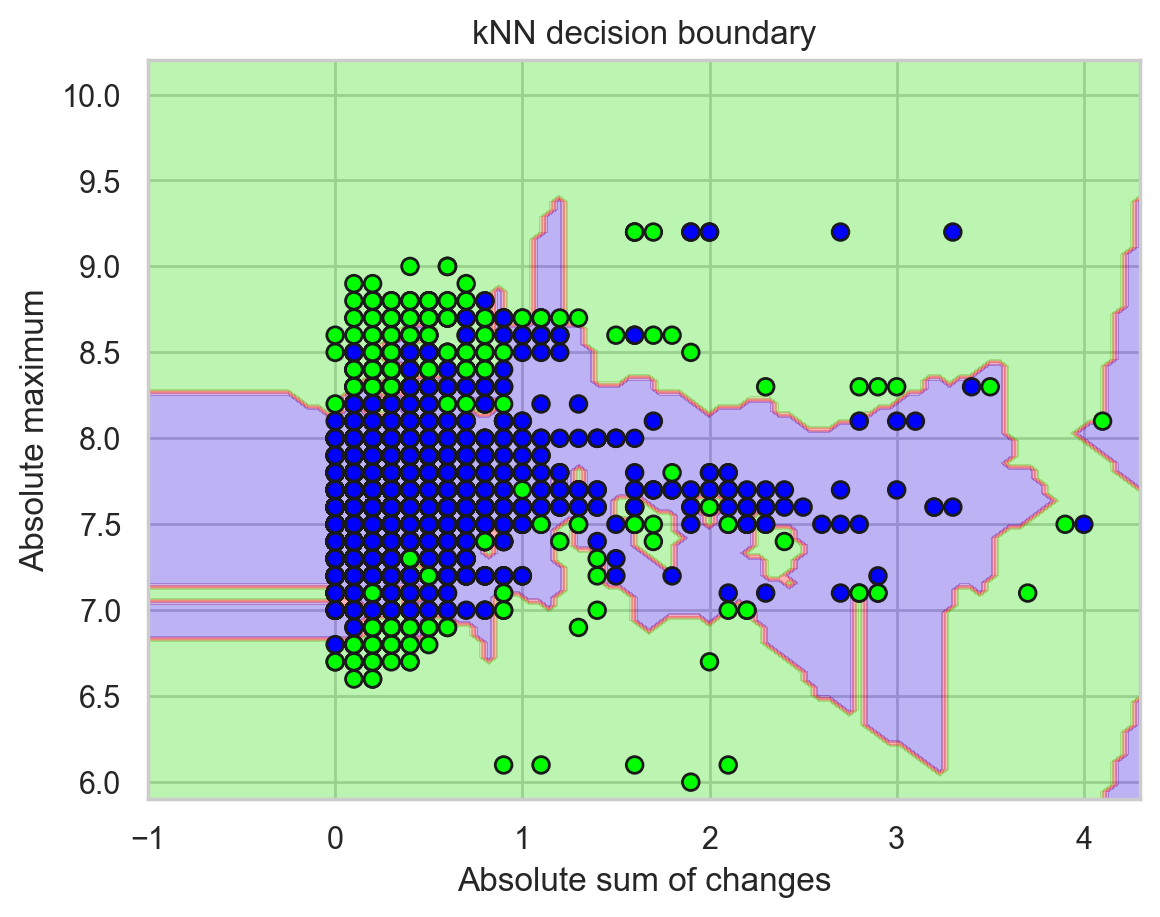

0 6 Absolute sum of changes Large standard deviation


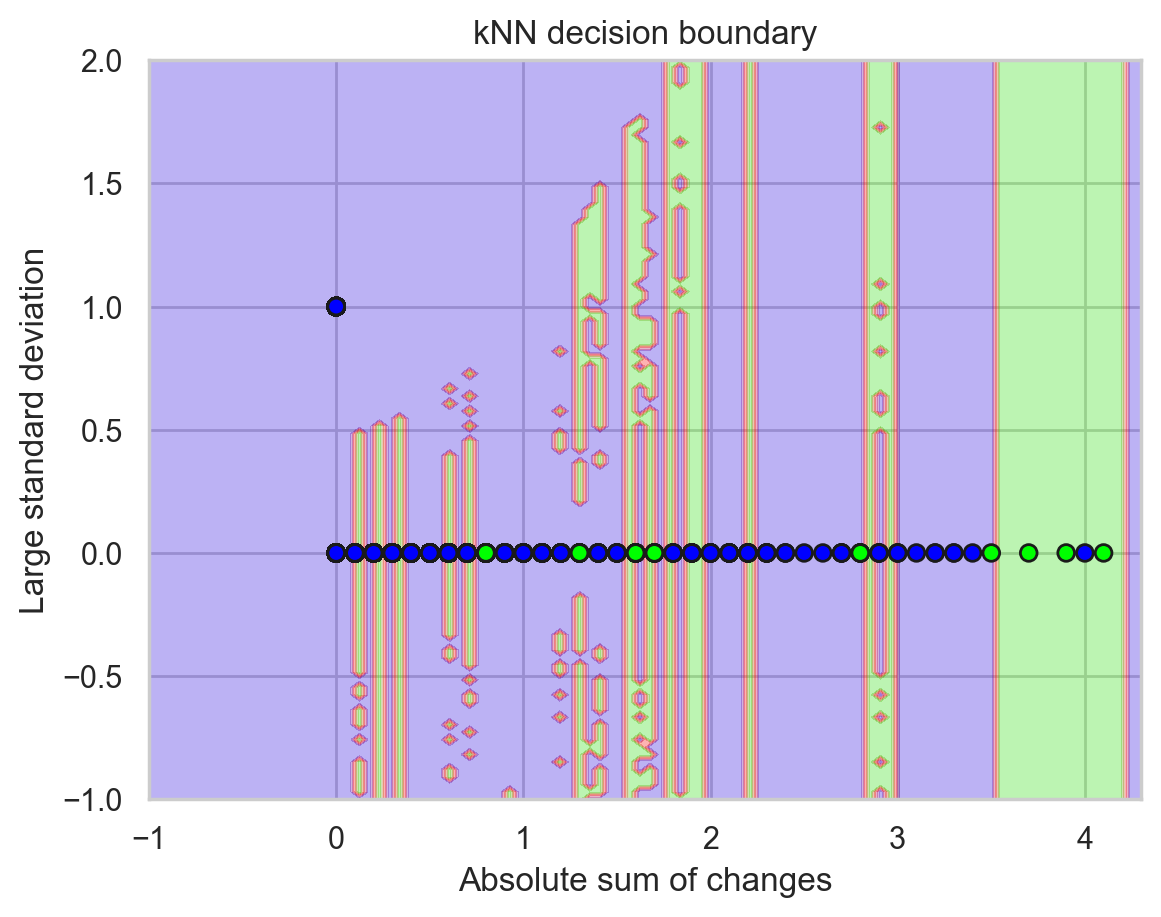

1 2 Autocorrelation Number of peaks


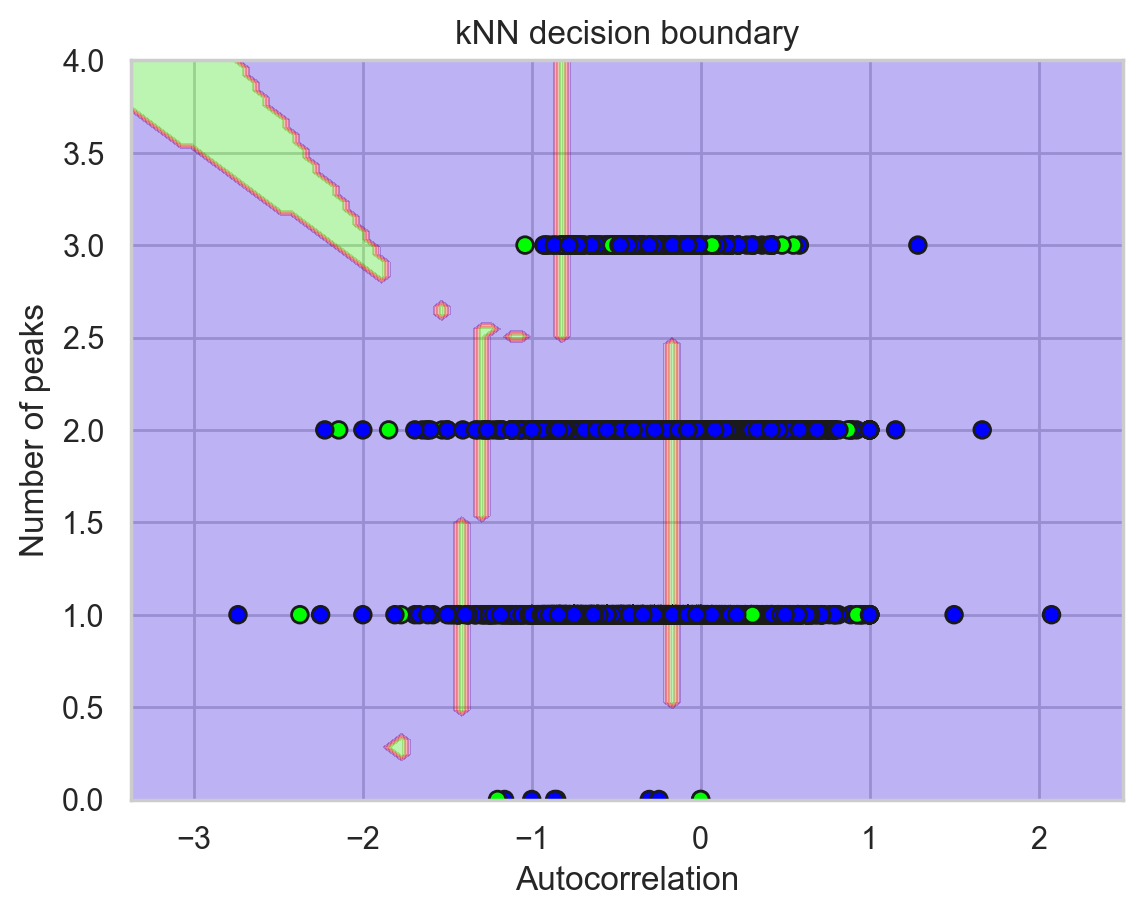

1 3 Autocorrelation Absolute complexity


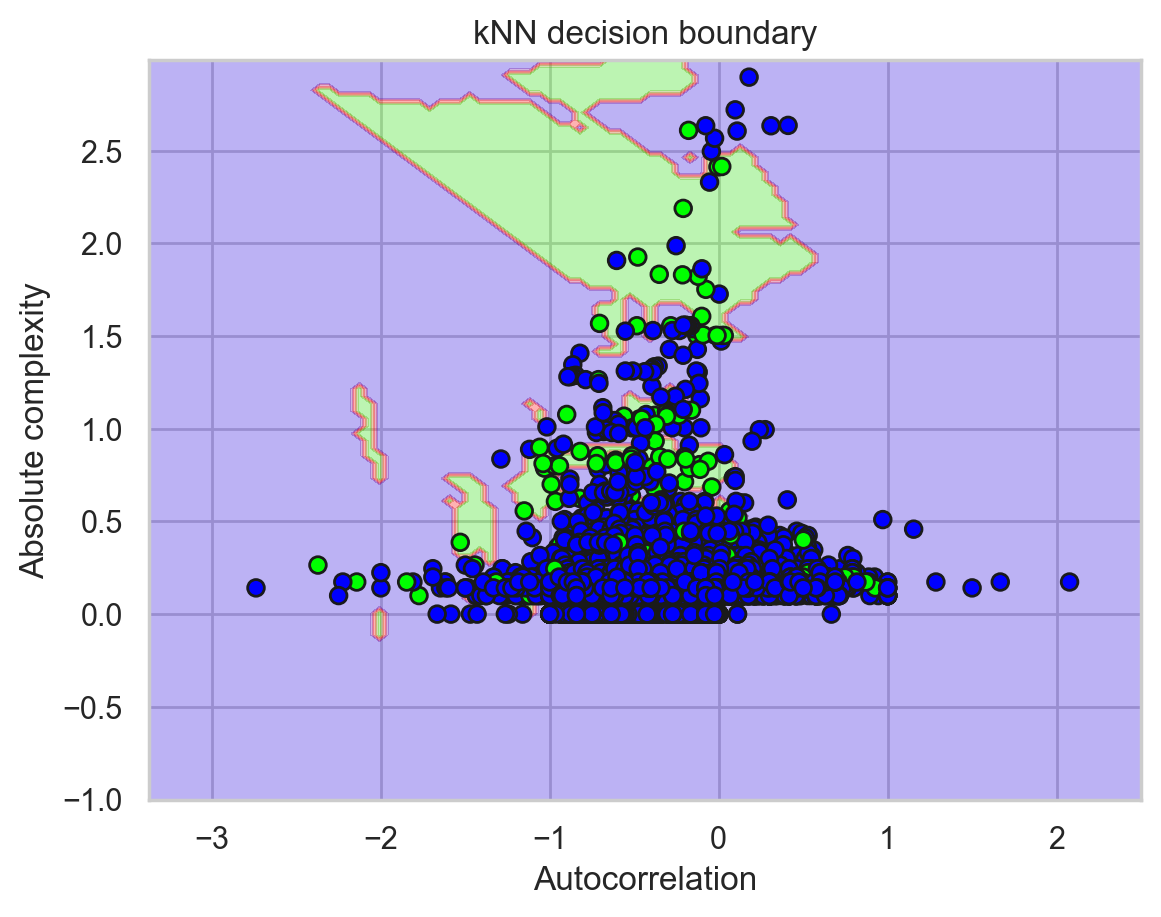

1 4 Autocorrelation VALUE


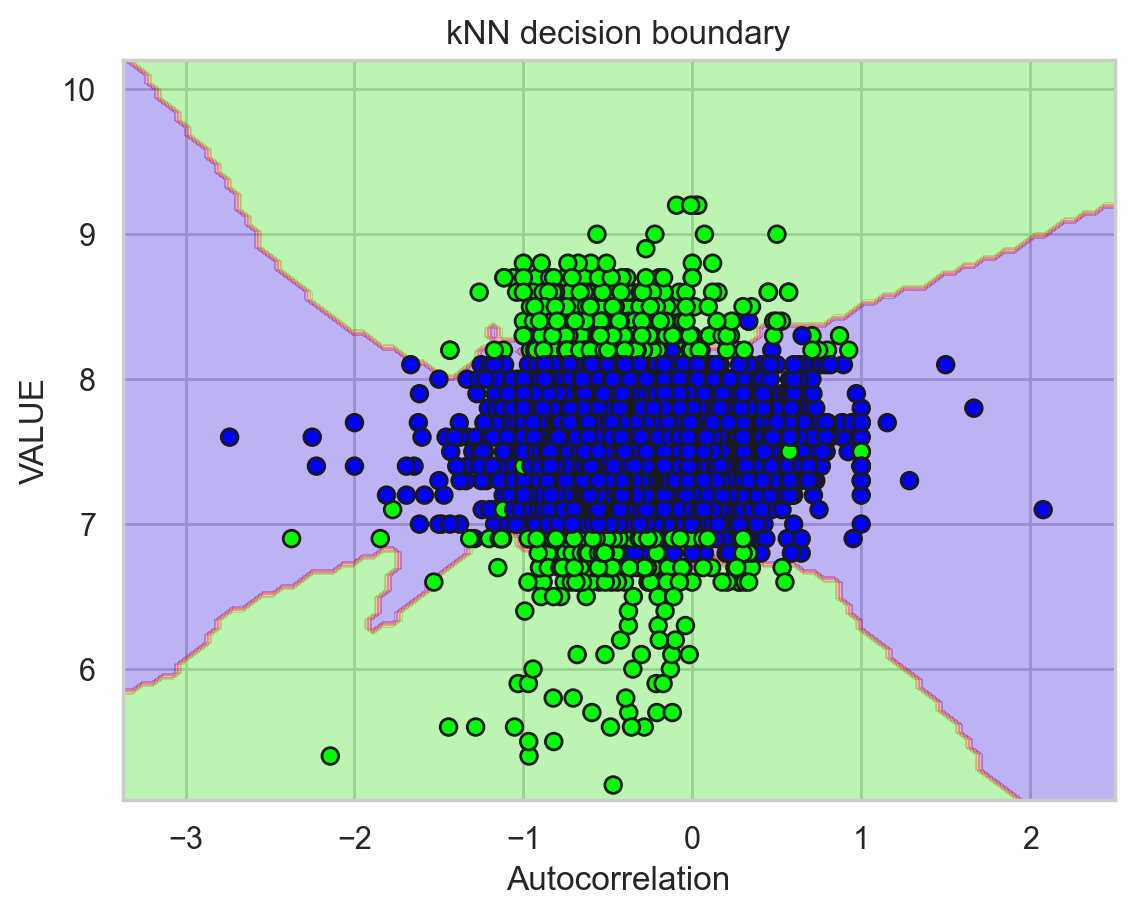

1 5 Autocorrelation Absolute maximum


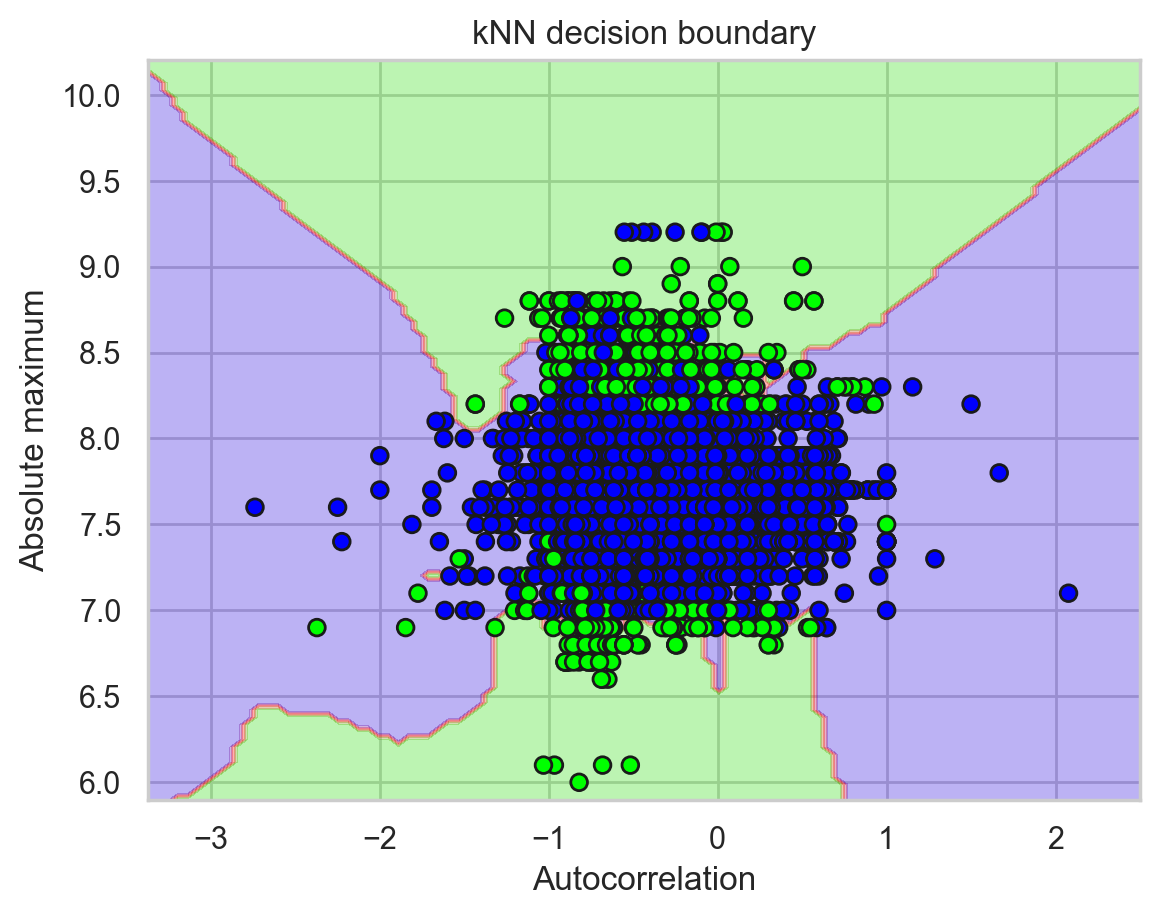

1 6 Autocorrelation Large standard deviation


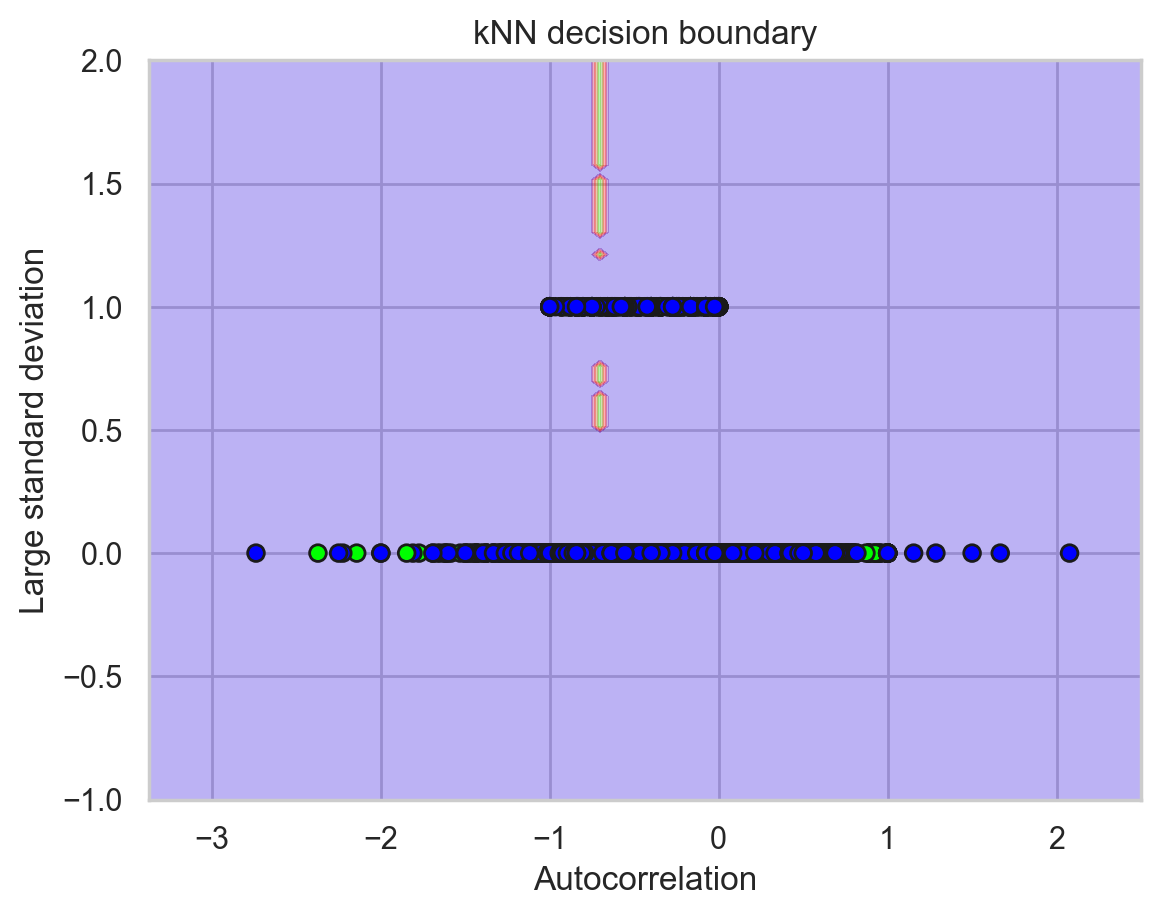

2 3 Number of peaks Absolute complexity


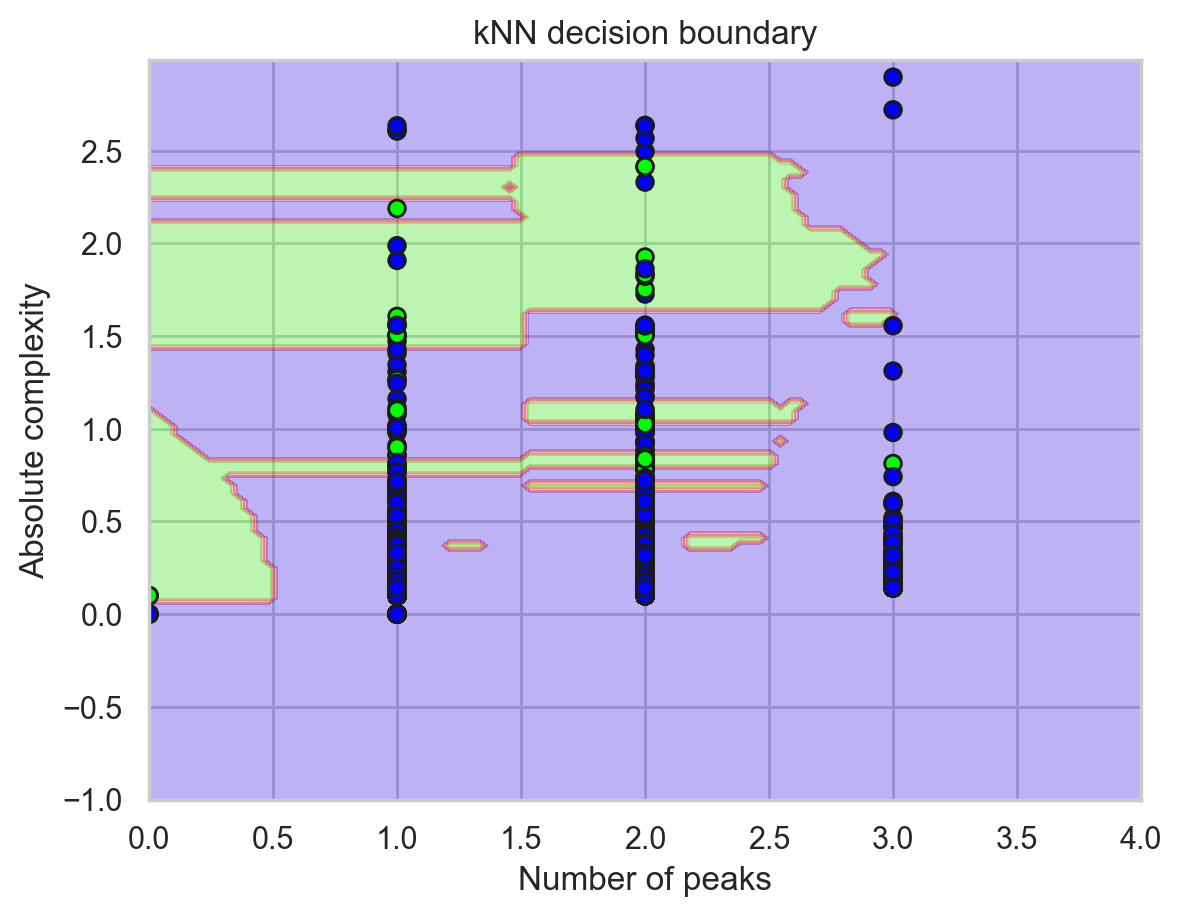

2 4 Number of peaks VALUE


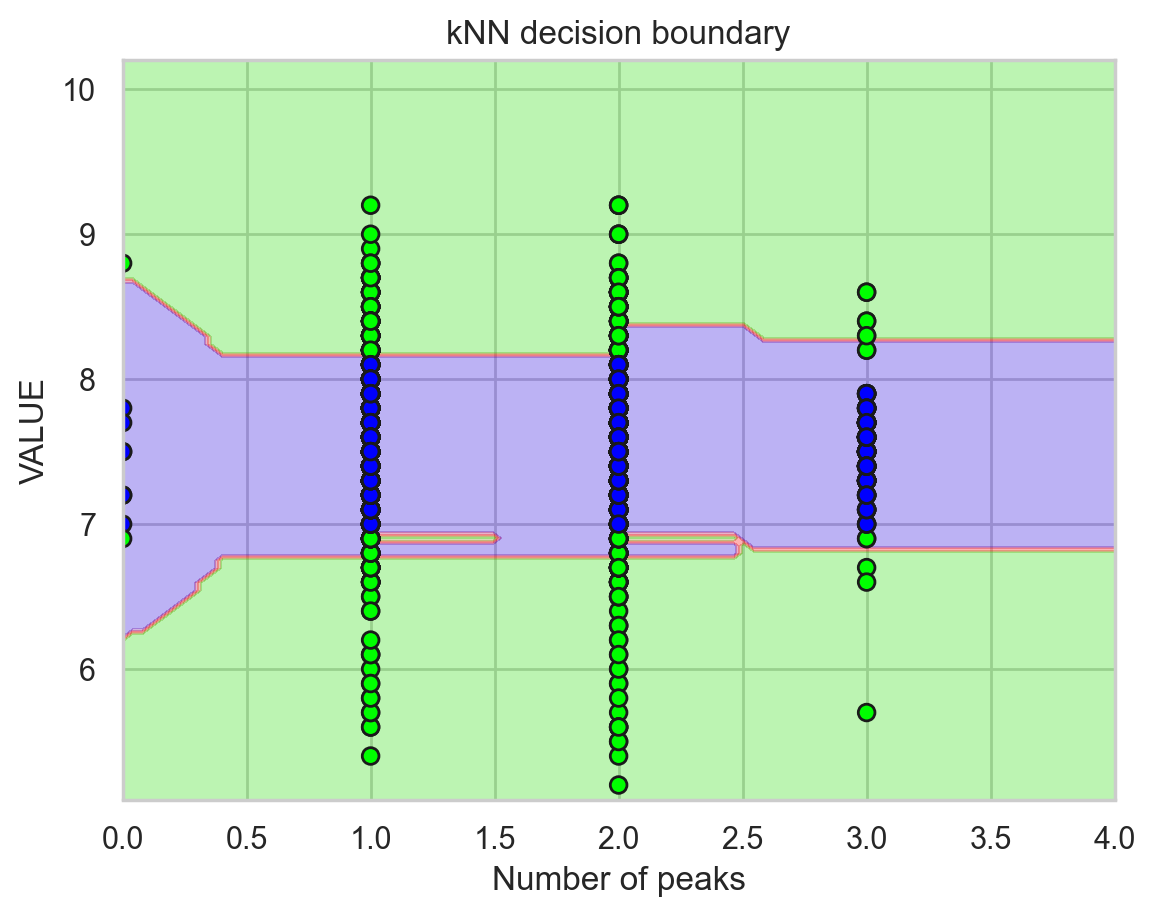

2 5 Number of peaks Absolute maximum


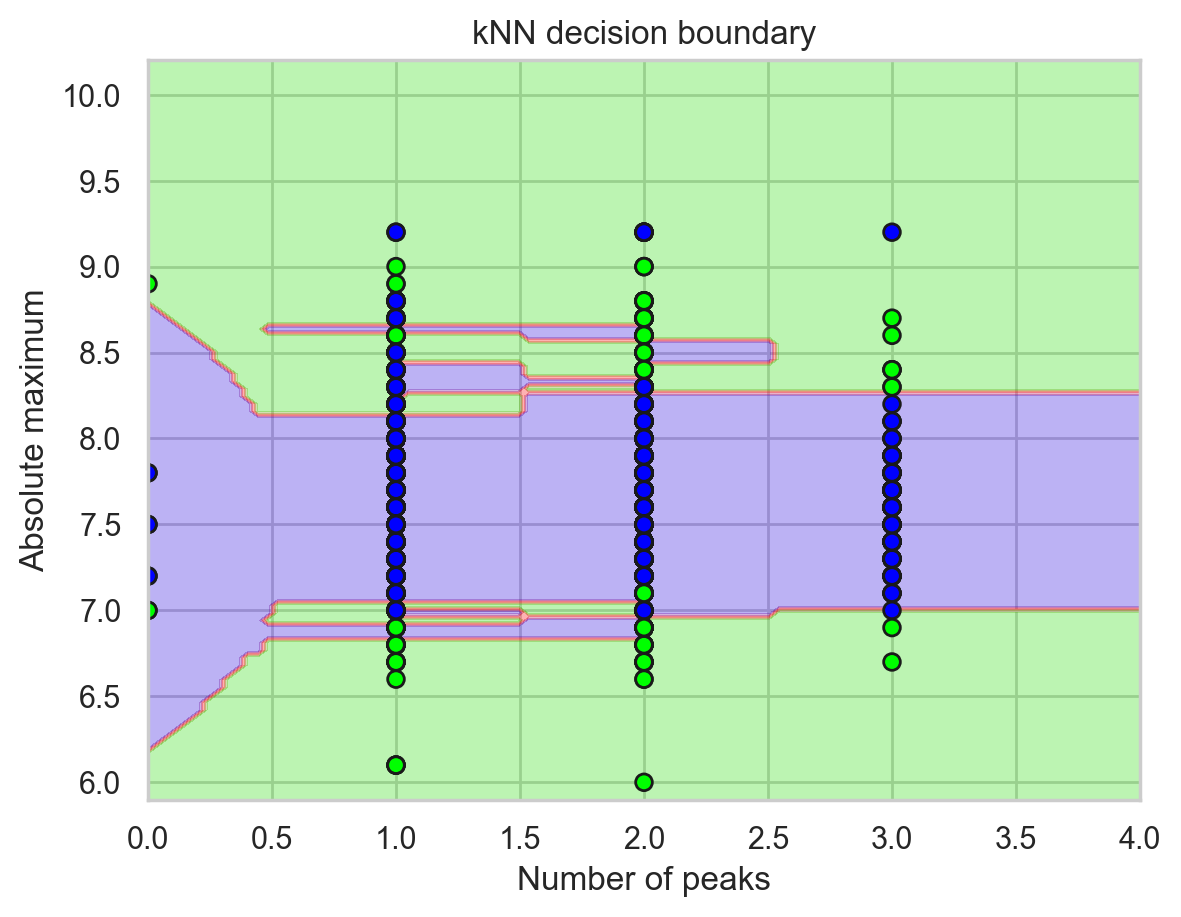

2 6 Number of peaks Large standard deviation


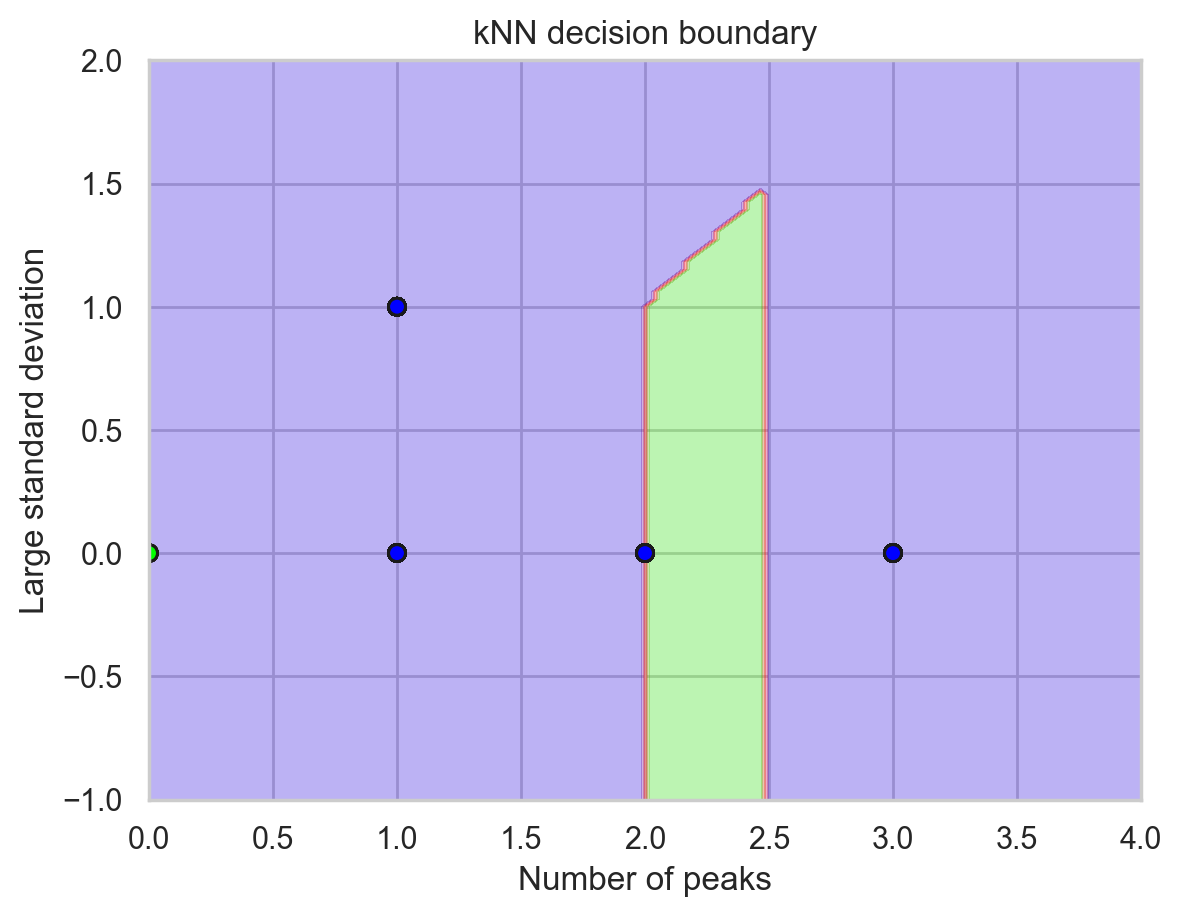

3 4 Absolute complexity VALUE


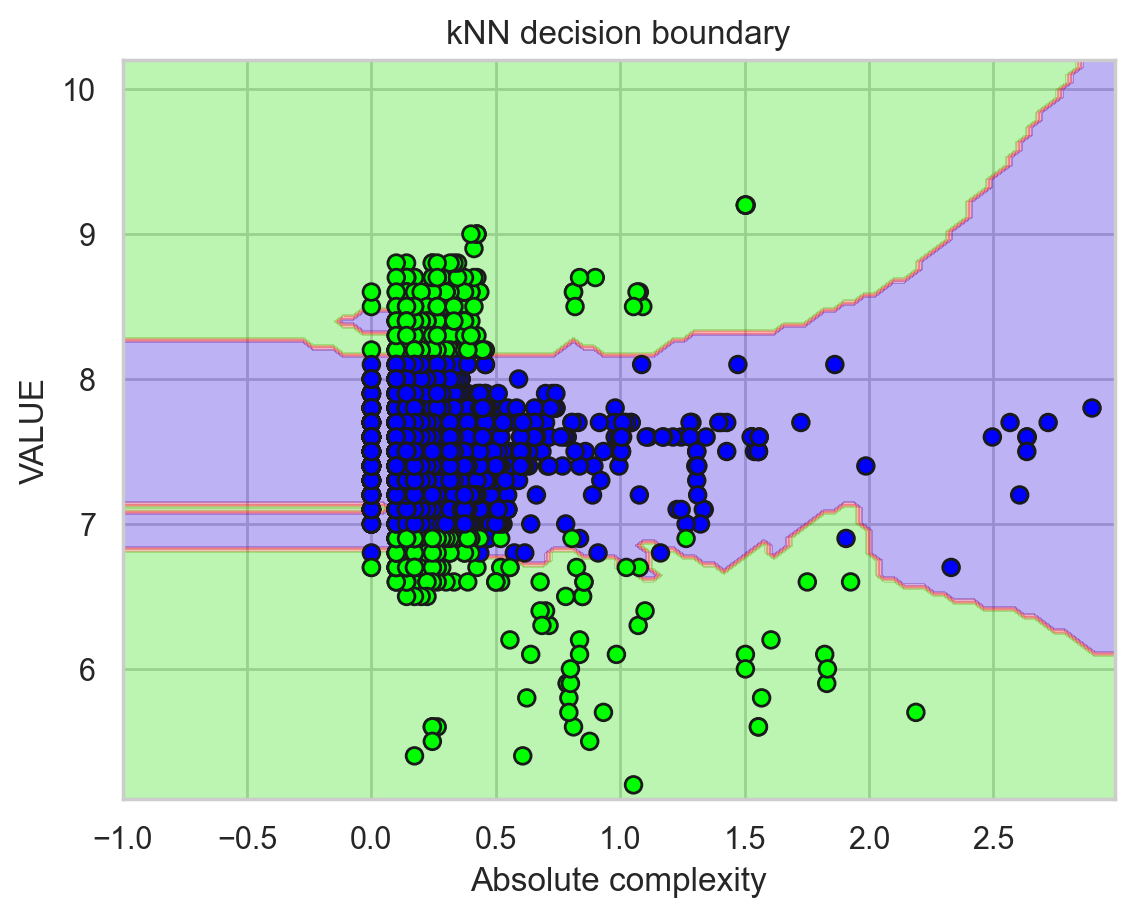

3 5 Absolute complexity Absolute maximum


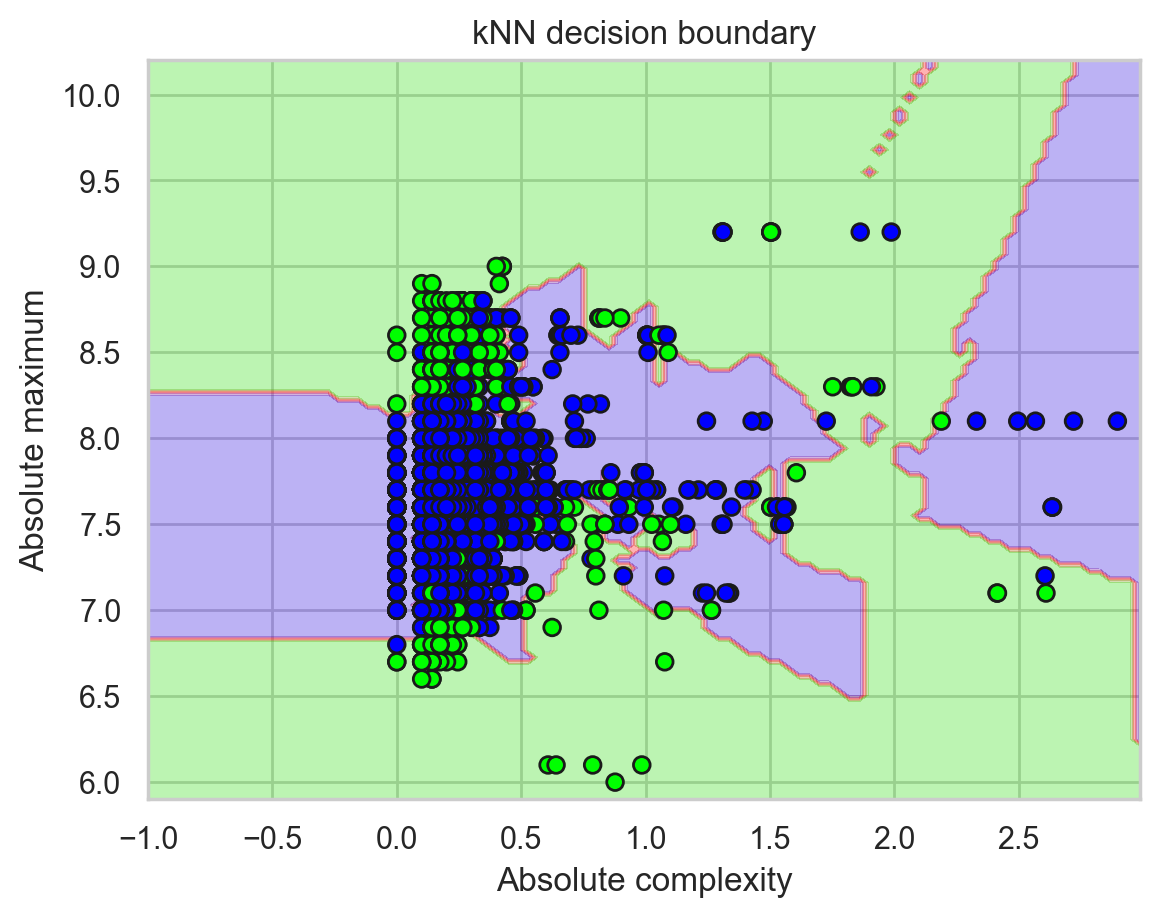

3 6 Absolute complexity Large standard deviation


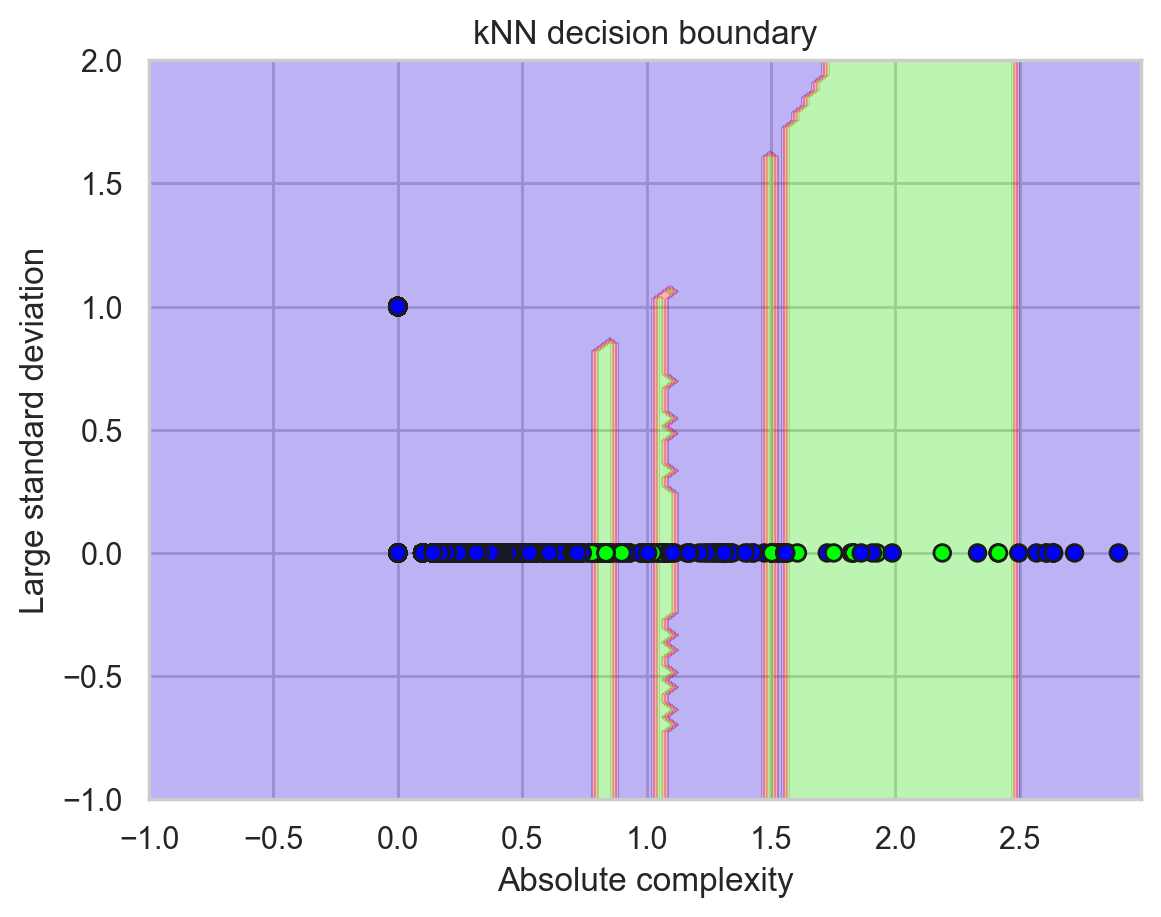

4 5 VALUE Absolute maximum


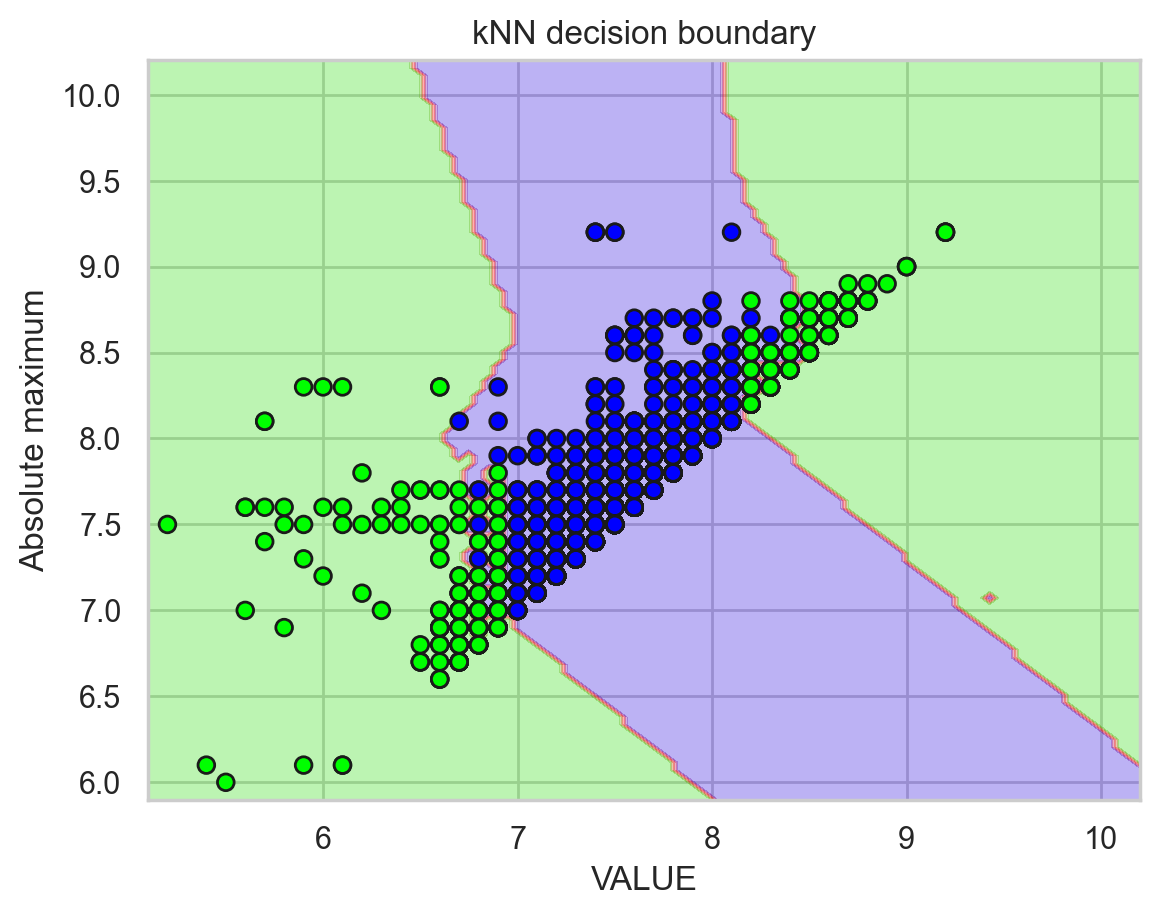

4 6 VALUE Large standard deviation


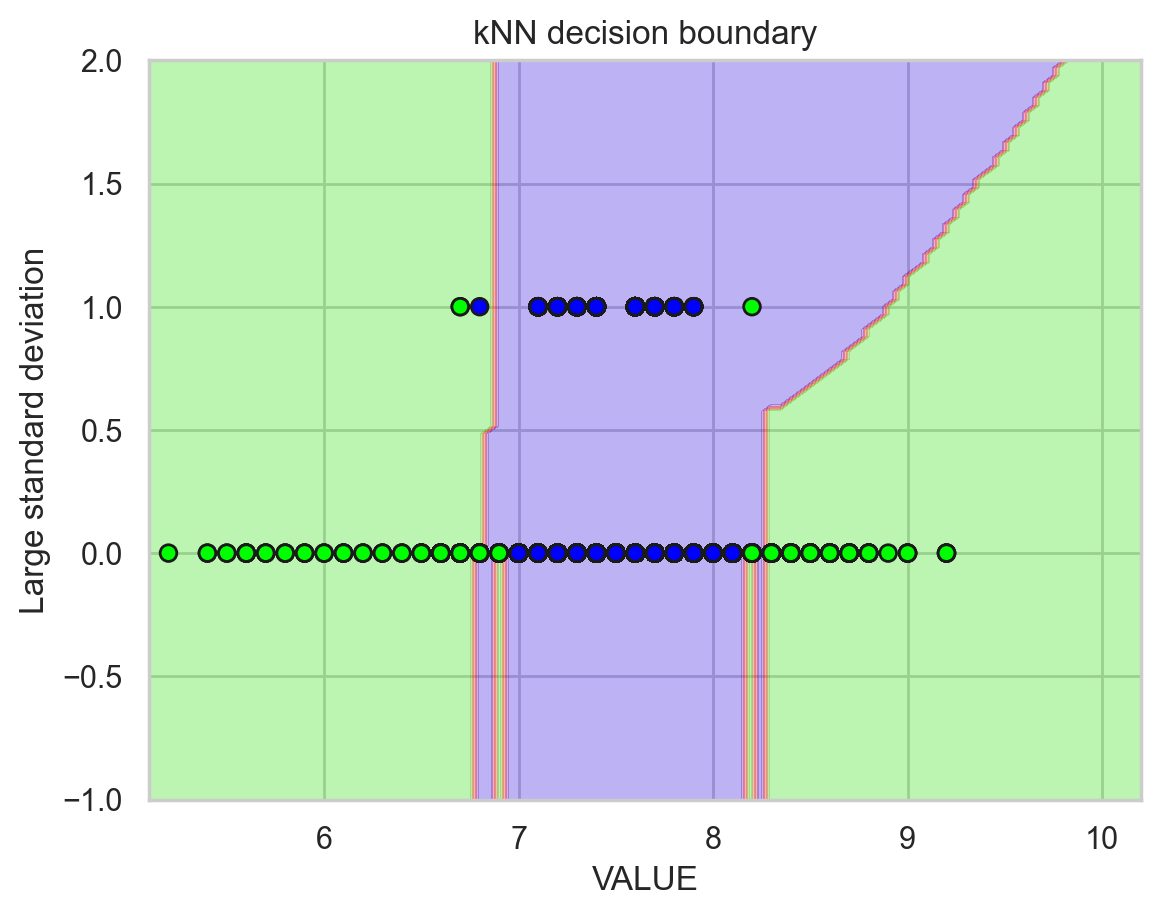

5 6 Absolute maximum Large standard deviation


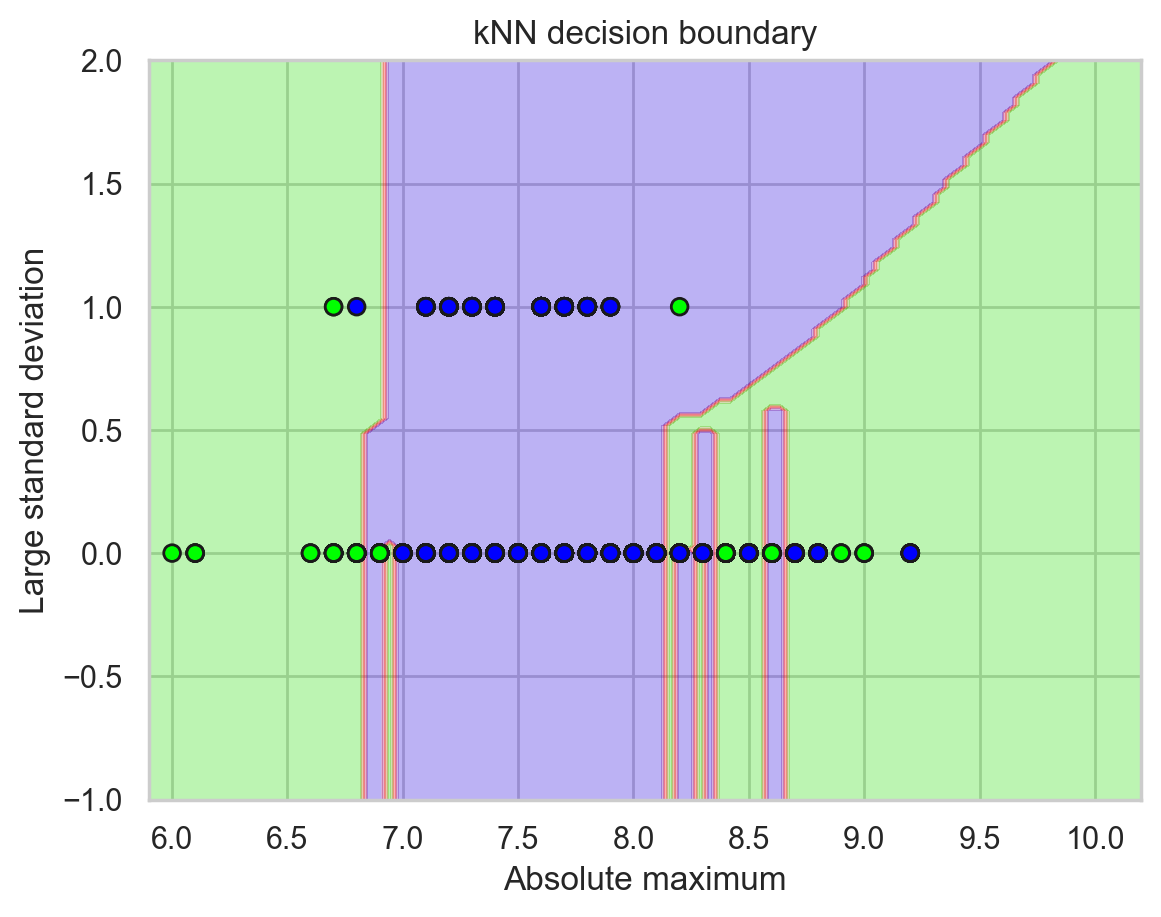

In [41]:
for i in range(len(pairs)):
    feature_x = pairs[i][0]
    feature_y = pairs[i][1]
    xlabel = X.columns[pairs[i][0]]
    ylabel = X.columns[pairs[i][1]]
    print(feature_x, feature_y, xlabel, ylabel)

    ax = plt.gca()
    clf.fit(X_train[:,[feature_x,feature_y]], y_train)

    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X_test[:,[feature_x,feature_y]],
        response_method="predict",
        cmap=plt.cm.brg,
        xlabel=xlabel,
        ylabel=ylabel,
        alpha=0.3,
        ax=ax,
    )

    x_range_values = ax.get_xlim()
    y_range_values = ax.get_ylim()
    
    scatter = disp.ax_.scatter(X.iloc[:, feature_x], X.iloc[:, feature_y], c=y,  cmap=plt.cm.brg, edgecolors="k")
    plt.xlim(x_range_values)
    plt.ylim(y_range_values)
    plt.title('kNN decision boundary')
    plt.show()